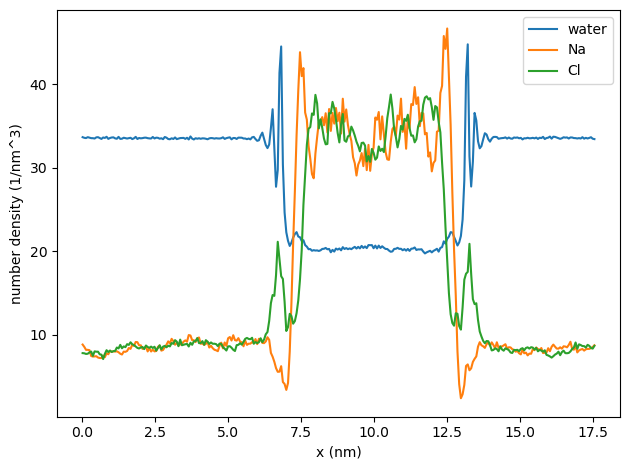

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("density_x_mean.csv")

plt.figure()
plt.plot(df["x_center_nm"], df["rho_water_mean"], label="water")
plt.plot(df["x_center_nm"], 20*df["rho_na_mean"], label="Na")
plt.plot(df["x_center_nm"], 20*df["rho_cl_mean"], label="Cl")
plt.xlabel("x (nm)")
plt.ylabel("number density (1/nm^3)")
plt.legend()
plt.tight_layout()
plt.show()


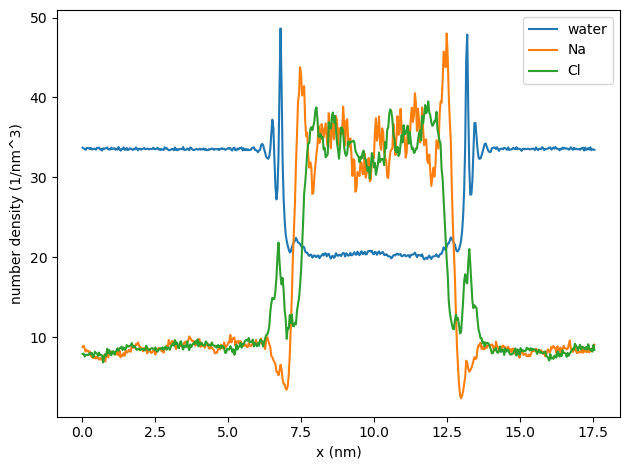

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("analysis_density_x.csv")

plt.figure()
plt.plot(df["x_center_nm"], df["rho_water_mean"], label="water")
plt.plot(df["x_center_nm"], 20*df["rho_na_mean"], label="Na")
plt.plot(df["x_center_nm"], 20*df["rho_cl_mean"], label="Cl")
plt.xlabel("x (nm)")
plt.ylabel("number density (1/nm^3)")
plt.legend()
plt.tight_layout()
plt.show()

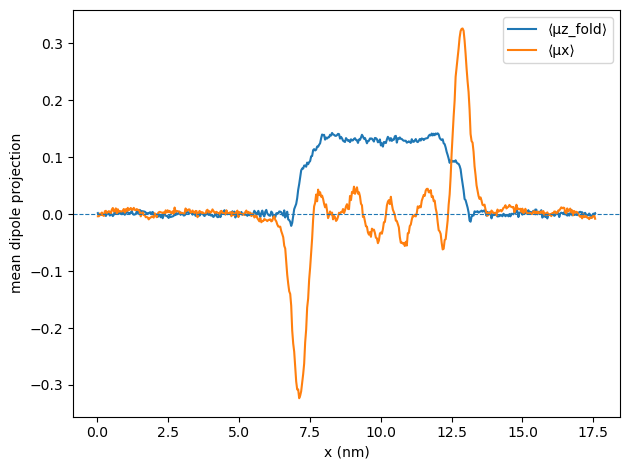

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("dipole_x_wholex.csv")
plt.figure()
plt.plot(df["x_center_nm"], df["muz_fold_mean"], label="⟨μz_fold⟩")
plt.plot(df["x_center_nm"], df["mux_mean"], label="⟨μx⟩")

plt.axhline(0.0, linestyle="--", linewidth=0.8)

plt.xlabel("x (nm)")
plt.ylabel("mean dipole projection")
plt.legend()
plt.tight_layout()
plt.show()


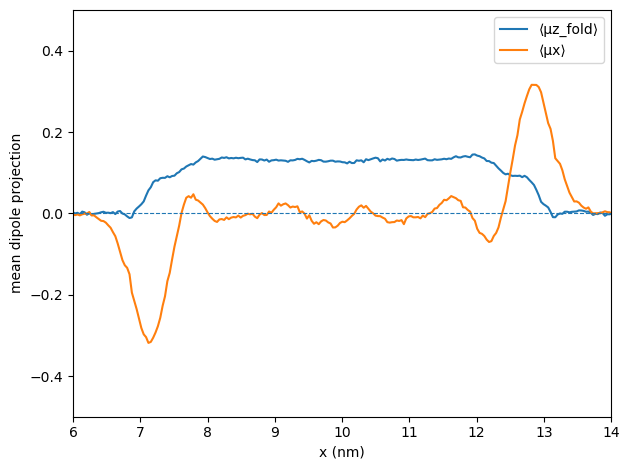

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("analysis_dipole_x.csv")
plt.figure()
plt.plot(df["x_center_nm"], df["muz_fold_mean"], label="⟨μz_fold⟩")
plt.plot(df["x_center_nm"], df["mux_mean"], label="⟨μx⟩")

plt.axhline(0.0, linestyle="--", linewidth=0.8)

plt.xlabel("x (nm)")
plt.xlim(6, 14.0)
plt.ylim(-0.5, 0.5)
plt.ylabel("mean dipole projection")
plt.legend()
plt.tight_layout()
plt.show()

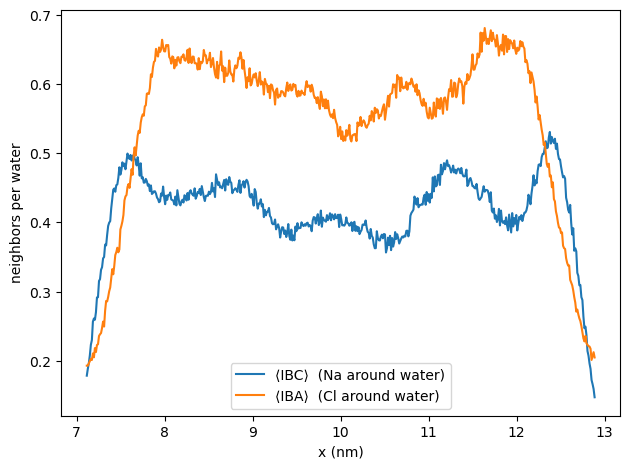

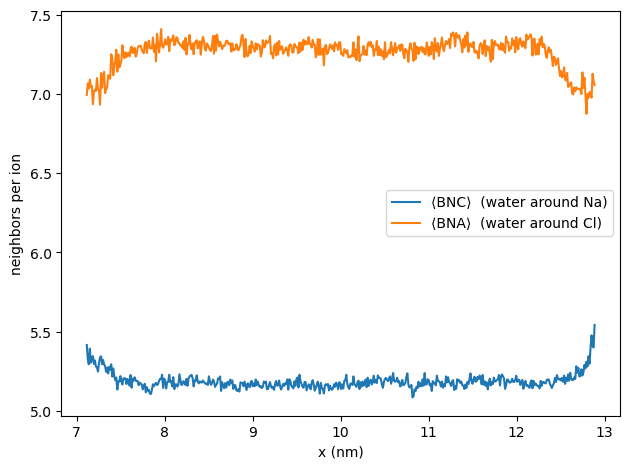

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("coord_x_mean.csv")

# Water-centric: IBC/IBA
plt.figure()
plt.plot(df["x_center_nm"], df["IBC_mean"], label="⟨IBC⟩  (Na around water)")
plt.plot(df["x_center_nm"], df["IBA_mean"], label="⟨IBA⟩  (Cl around water)")
plt.xlabel("x (nm)")
plt.ylabel("neighbors per water")
plt.legend()
plt.tight_layout()
plt.show()

# Ion-centric: BNC/BNA
plt.figure()
plt.plot(df["x_center_nm"], df["BNC_mean"], label="⟨BNC⟩  (water around Na)")
plt.plot(df["x_center_nm"], df["BNA_mean"], label="⟨BNA⟩  (water around Cl)")
plt.xlabel("x (nm)")
plt.ylabel("neighbors per ion")
plt.legend()
plt.tight_layout()
plt.show()


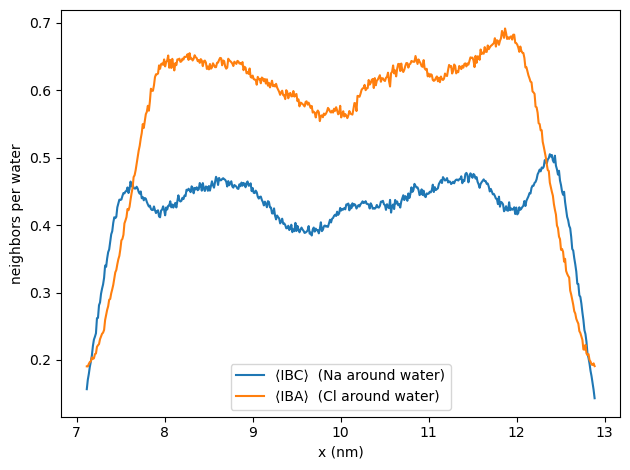

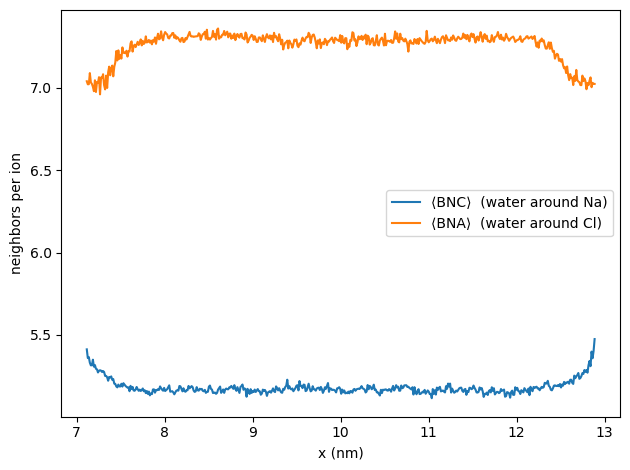

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("analysis_coord_x.csv")

# Water-centric: IBC/IBA
plt.figure()
plt.plot(df["x_center_nm"], df["IBC_mean"], label="⟨IBC⟩  (Na around water)")
plt.plot(df["x_center_nm"], df["IBA_mean"], label="⟨IBA⟩  (Cl around water)")
plt.xlabel("x (nm)")
plt.ylabel("neighbors per water")
plt.legend()
plt.tight_layout()
plt.show()

# Ion-centric: BNC/BNA
plt.figure()
plt.plot(df["x_center_nm"], df["BNC_mean"], label="⟨BNC⟩  (water around Na)")
plt.plot(df["x_center_nm"], df["BNA_mean"], label="⟨BNA⟩  (water around Cl)")
plt.xlabel("x (nm)")
plt.ylabel("neighbors per ion")
plt.legend()
plt.tight_layout()
plt.show()


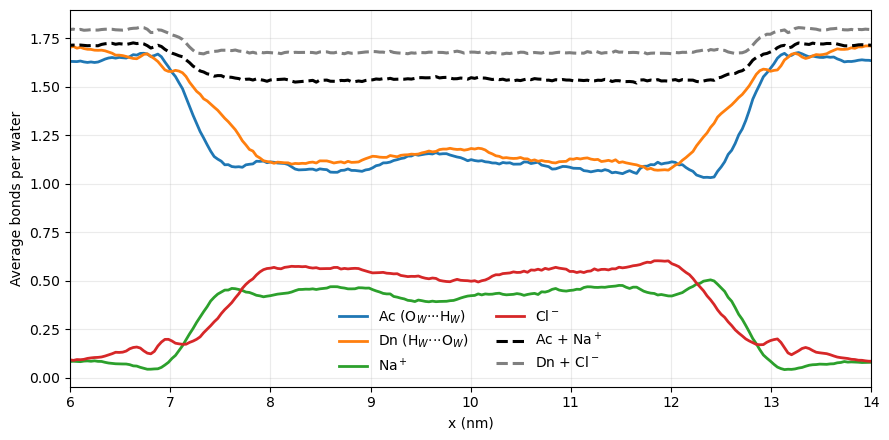

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

# from unified run: <prefix>_coord_x.csv
df = pd.read_csv("analysis_coord_x.csv")

x = df["x_center_nm"]

# Bottom-panel series
ac  = df["HBww_acc_mean"]   # O_W accepts from H_W
dn  = df["HBww_don_mean"]   # H_W donates to O_W
na  = df["IBC_mean"]        # O_W -- Na+ coordination proxy
clm = df["HBwcl_don_mean"]  # H_W -- Cl- donation

sum_o = ac + na   # Ac + Na+
sum_h = dn + clm  # Dn + Cl-

fig, ax = plt.subplots(figsize=(9,4.5))

ax.plot(x, ac,  label="Ac (O$_W$···H$_W$)", lw=2.0)
ax.plot(x, dn,  label="Dn (H$_W$···O$_W$)", lw=2.0)
ax.plot(x, na,  label="Na$^+$", lw=2.0)
ax.plot(x, clm, label="Cl$^-$", lw=2.0)

# dashed sums
ax.plot(x, sum_o, "--", label="Ac + Na$^+$", lw=2.2, color="black")
ax.plot(x, sum_h, "--", label="Dn + Cl$^-$", lw=2.2, color="gray")

# optional: channel edges (set your values)
# x_left, x_right = 7.11, 12.89
# ax.axvline(x_left,  ls=":", color="k")
# ax.axvline(x_right, ls=":", color="k")
plt.xlim(6, 14)
ax.set_xlabel("x (nm)")
ax.set_ylabel("Average bonds per water")
ax.grid(alpha=0.25)
ax.legend(ncol=2, frameon=False)
plt.tight_layout()
plt.show()


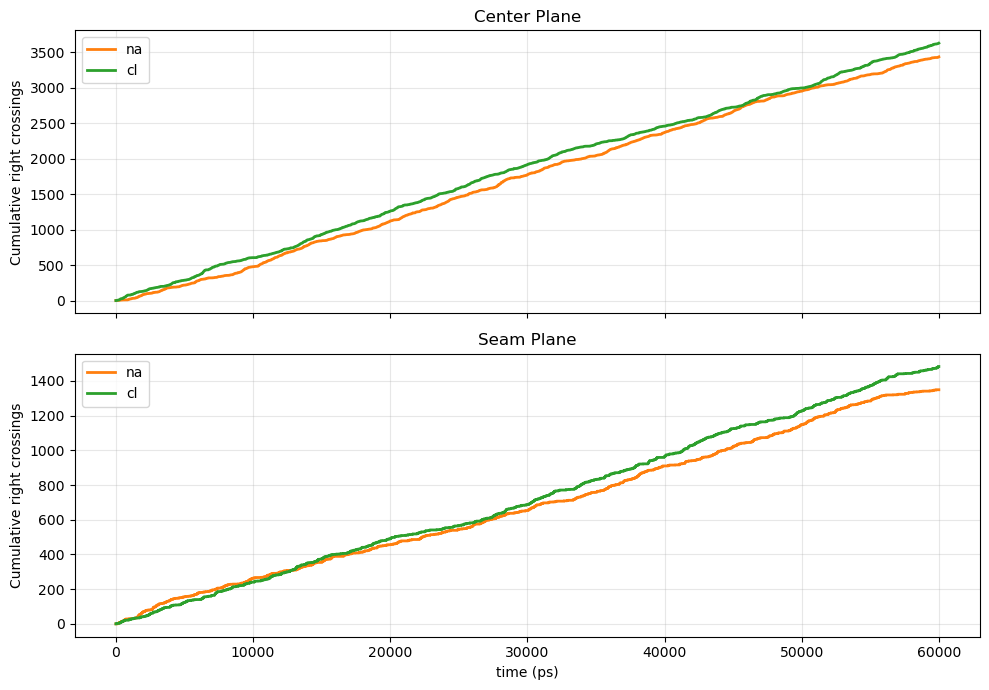

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("analysis_gating_flux.csv")   # change prefix if needed

species = [ "na", "cl"]
colors = { "na":"tab:orange", "cl":"tab:green"}

fig, ax = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

# Center plane: cumulative right crossings
for sp in species:
    ax[0].plot(df["time_ps"], df[f"center_{sp}_cum_right"], label=sp, lw=2, color=colors[sp])
ax[0].set_title("Center Plane")
ax[0].set_ylabel("Cumulative right crossings")
ax[0].grid(alpha=0.3)
ax[0].legend()

# Seam plane: cumulative right crossings
for sp in species:
    ax[1].plot(df["time_ps"], df[f"seam_{sp}_cum_right"], label=sp, lw=2, color=colors[sp])
ax[1].set_title("Seam Plane")
ax[1].set_xlabel("time (ps)")
ax[1].set_ylabel("Cumulative right crossings")
ax[1].grid(alpha=0.3)
ax[1].legend()

plt.tight_layout()
plt.show()


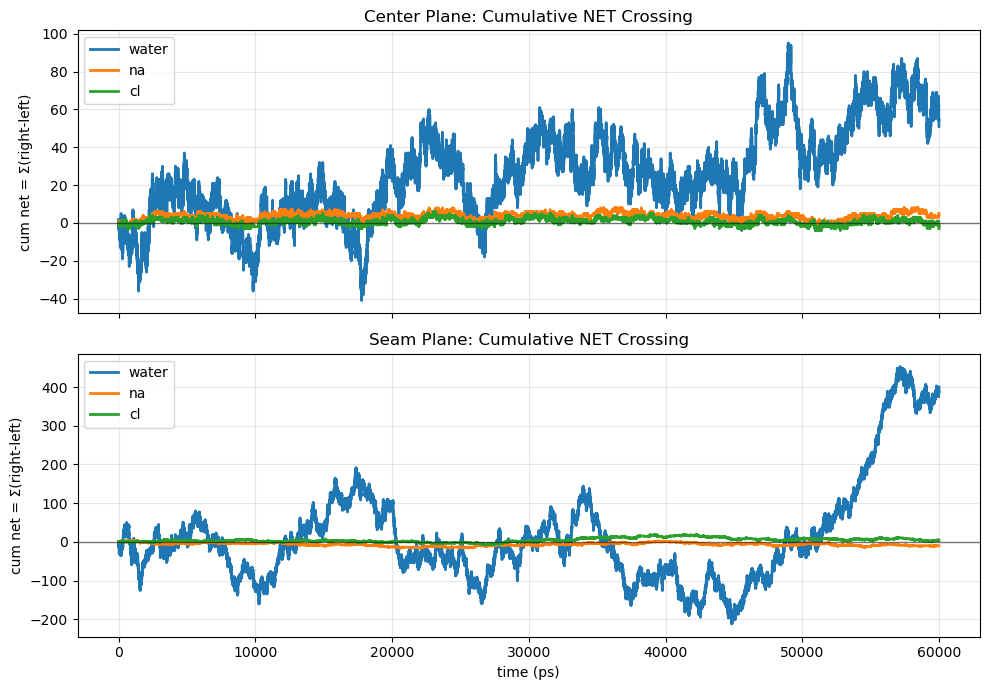

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("analysis_gating_flux.csv")  # change if needed
species = ["water", "na", "cl"]
colors = {"water":"tab:blue", "na":"tab:orange", "cl":"tab:green"}

# Build cumulative NET crossing = cumsum(right - left)
for sp in species:
    df[f"center_{sp}_net_cum"] = (df[f"center_{sp}_right"] - df[f"center_{sp}_left"]).cumsum()
    df[f"seam_{sp}_net_cum"]   = (df[f"seam_{sp}_right"]   - df[f"seam_{sp}_left"]).cumsum()

fig, ax = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

# Center net cumulative
for sp in species:
    ax[0].plot(df["time_ps"], df[f"center_{sp}_net_cum"], label=sp, lw=2, color=colors[sp])
ax[0].axhline(0, color="k", lw=1, alpha=0.5)
ax[0].set_title("Center Plane: Cumulative NET Crossing")
ax[0].set_ylabel("cum net = Σ(right-left)")
ax[0].grid(alpha=0.3)
ax[0].legend()

# Seam net cumulative
for sp in species:
    ax[1].plot(df["time_ps"], df[f"seam_{sp}_net_cum"], label=sp, lw=2, color=colors[sp])
ax[1].axhline(0, color="k", lw=1, alpha=0.5)
ax[1].set_title("Seam Plane: Cumulative NET Crossing")
ax[1].set_xlabel("time (ps)")
ax[1].set_ylabel("cum net = Σ(right-left)")
ax[1].grid(alpha=0.3)
ax[1].legend()

plt.tight_layout()
plt.show()


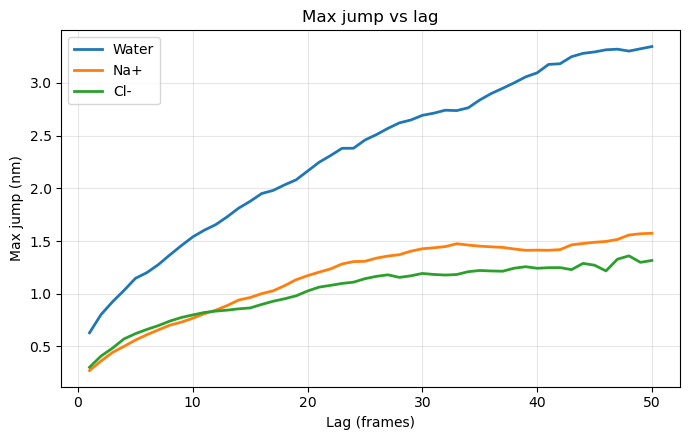

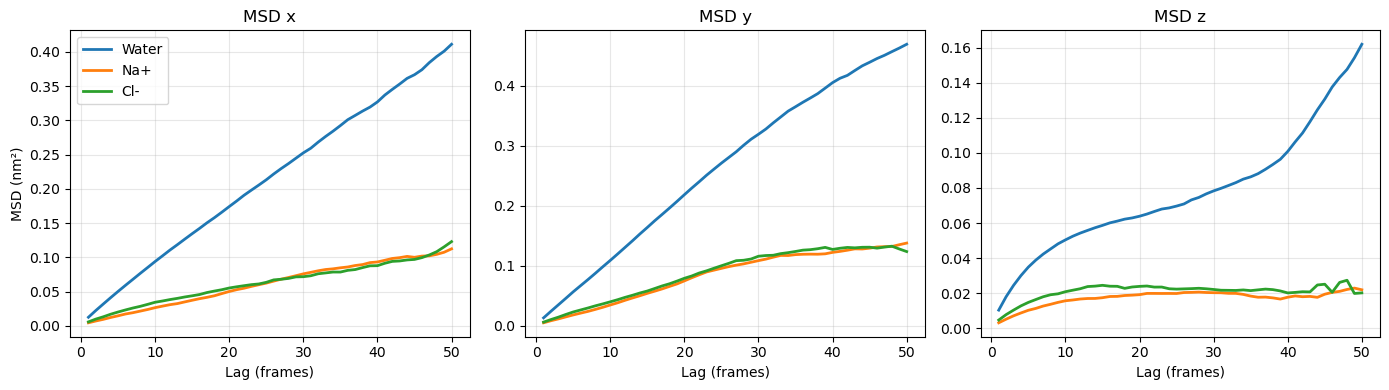

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("analysis_jump_msd.csv")

fig, ax = plt.subplots(figsize=(7,4.5))
ax.plot(df["lag_frames"], df["max_jump_water_nm_mean"], label="Water", lw=2)
ax.plot(df["lag_frames"], df["max_jump_na_nm_mean"], label="Na+", lw=2)
ax.plot(df["lag_frames"], df["max_jump_cl_nm_mean"], label="Cl-", lw=2)

ax.set_xlabel("Lag (frames)")
ax.set_ylabel("Max jump (nm)")
ax.set_title("Max jump vs lag")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()
fig, axs = plt.subplots(1, 3, figsize=(14,4), sharex=True)

for ax, comp in zip(axs, ["x", "y", "z"]):
    ax.plot(df["lag_frames"], df[f"msd_{comp}_water_nm2_mean"], label="Water", lw=2)
    ax.plot(df["lag_frames"], df[f"msd_{comp}_na_nm2_mean"], label="Na+", lw=2)
    ax.plot(df["lag_frames"], df[f"msd_{comp}_cl_nm2_mean"], label="Cl-", lw=2)
    ax.set_title(f"MSD {comp}")
    ax.set_xlabel("Lag (frames)")
    ax.grid(alpha=0.3)

axs[0].set_ylabel("MSD (nm²)")
axs[0].legend()
plt.tight_layout()
plt.show()


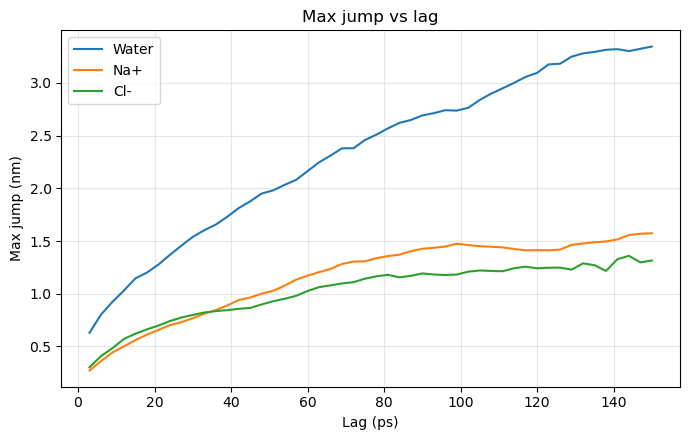

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("analysis_jump_msd.csv")

dt_ps = 3.0  # your frame spacing (adjust if needed)
df["lag_ps"] = df["lag_frames"] * dt_ps

plt.figure(figsize=(7,4.5))

plt.plot(df["lag_ps"], df["max_jump_water_nm_mean"], label="Water")
plt.plot(df["lag_ps"], df["max_jump_na_nm_mean"], label="Na+")
plt.plot(df["lag_ps"], df["max_jump_cl_nm_mean"], label="Cl-")

plt.xlabel("Lag (ps)")
plt.ylabel("Max jump (nm)")
plt.title("Max jump vs lag")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

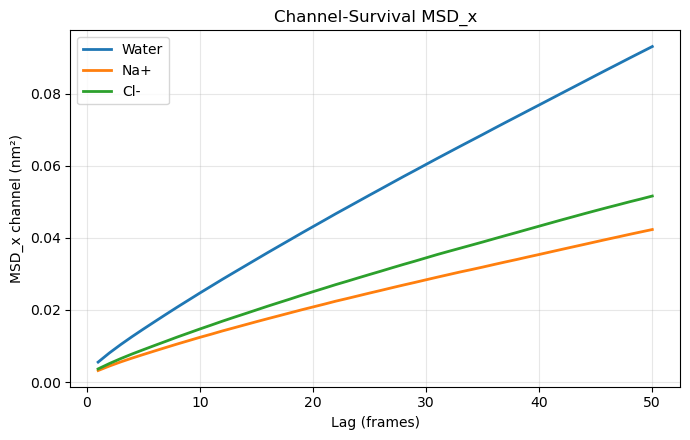

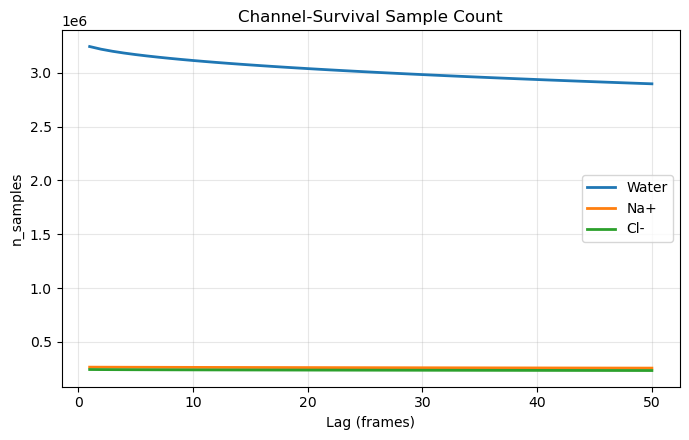

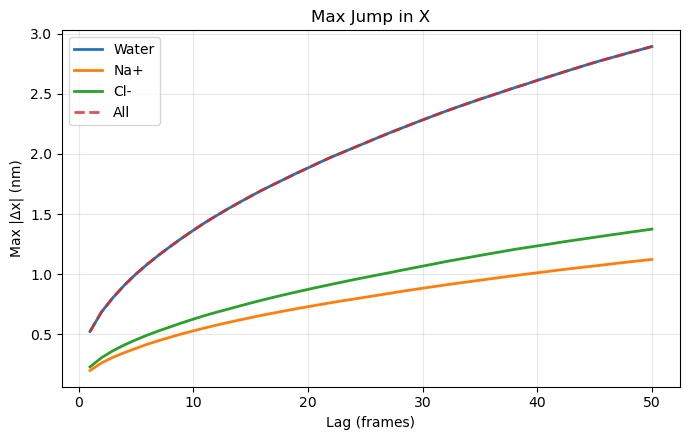

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# user settings
# -----------------------------
dt_ps = 3.0          # frame spacing in ps (CHANGE if needed)
ps_to_ns = 1e-3
eps = 1e-30          # avoid log(0)

# -----------------------------
# load data
# -----------------------------
df_ch = pd.read_csv("analysis_msd_x_channel.csv")
df_j  = pd.read_csv("analysis_jump_msd.csv")

# add lag time
df_ch["lag_ps"] = df_ch["lag_frames"] * dt_ps
df_ch["lag_ns"] = df_ch["lag_ps"] * ps_to_ns
df_j["lag_ps"]  = df_j["lag_frames"] * dt_ps
df_j["lag_ns"]  = df_j["lag_ps"] * ps_to_ns

# -----------------------------
# helpers
# -----------------------------
def local_loglog_slope(x, y):
    """alpha = d log(y) / d log(x) using numpy gradient. x,y must be >0."""
    x = np.asarray(x)
    y = np.asarray(y)
    m = (x > 0) & (y > 0) & np.isfinite(x) & np.isfinite(y)
    alpha = np.full_like(x, np.nan, dtype=float)
    if m.sum() >= 3:
        lx = np.log(x[m])
        ly = np.log(y[m])
        alpha_m = np.gradient(ly, lx)
        alpha[m] = alpha_m
    return alpha

def effective_D_1d(t, msd):
    """
    Effective diffusion coefficient from 1D MSD:
    D(t) ~ (1/2) d(MSD)/dt
    t in ns, msd in nm^2 -> D in nm^2/ns
    """
    t = np.asarray(t)
    msd = np.asarray(msd)
    m = np.isfinite(t) & np.isfinite(msd)
    D = np.full_like(t, np.nan, dtype=float)
    if m.sum() >= 3:
        dmsd_dt = np.gradient(msd[m], t[m])
        D[m] = 0.5 * dmsd_dt
    return D

# -----------------------------
# 1) Channel-survival MSD_x + sample counts
# -----------------------------
fig, ax = plt.subplots(figsize=(7,4.5))
ax.plot(df_ch["lag_frames"], df_ch["msd_x_channel_water_nm2_mean"], label="Water", lw=2)
ax.plot(df_ch["lag_frames"], df_ch["msd_x_channel_na_nm2_mean"], label="Na+", lw=2)
ax.plot(df_ch["lag_frames"], df_ch["msd_x_channel_cl_nm2_mean"], label="Cl-", lw=2)
ax.set_xlabel("Lag (frames)")
ax.set_ylabel("MSD_x channel (nm²)")
ax.set_title("Channel-Survival MSD_x")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7,4.5))
ax.plot(df_ch["lag_frames"], df_ch["n_samples_water"], label="Water", lw=2)
ax.plot(df_ch["lag_frames"], df_ch["n_samples_na"], label="Na+", lw=2)
ax.plot(df_ch["lag_frames"], df_ch["n_samples_cl"], label="Cl-", lw=2)
ax.set_xlabel("Lag (frames)")
ax.set_ylabel("n_samples")
ax.set_title("Channel-Survival Sample Count")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

# -----------------------------
# 2) Max jump in x
# -----------------------------
fig, ax = plt.subplots(figsize=(7,4.5))
ax.plot(df_j["lag_frames"], df_j["max_jump_x_water_nm_mean"], label="Water", lw=2)
ax.plot(df_j["lag_frames"], df_j["max_jump_x_na_nm_mean"], label="Na+", lw=2)
ax.plot(df_j["lag_frames"], df_j["max_jump_x_cl_nm_mean"], label="Cl-", lw=2)
if "max_jump_x_nm_mean" in df_j.columns:
    ax.plot(df_j["lag_frames"], df_j["max_jump_x_nm_mean"], label="All", lw=2, ls="--", alpha=0.8)
ax.set_xlabel("Lag (frames)")
ax.set_ylabel("Max |Δx| (nm)")
ax.set_title("Max Jump in X")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

# -----------------------------
# 3) MSD_y and MSD_z (z-slab restricted) + expected checks (alpha and D)
# -----------------------------
species = [("water", "Water"), ("na", "Na+"), ("cl", "Cl-")]

# --- MSD_y and MSD_z plots
fig, axs = plt.subplots(1, 2, figsize=(12,4.5), sharex=True)

for key, label in species:
    axs[0].plot(df_j["lag_frames"], df_j[f"msd_y_{key}_nm2_mean"], label=label, lw=2)
axs[0].set_title("MSD_y vs Lag")
axs[0].set_xlabel("Lag (frames)")
axs[0].set_ylabel("MSD (nm²)")
axs[0].grid(alpha=0.3)
axs[0].legend()

for key, label in species:
    axs[1].plot(df_j["lag_frames"], df_j[f"msd_z_{key}_nm2_mean"], label=label, lw=2)
axs[1].set_title("MSD_z vs Lag")
axs[1].set_xlabel("Lag (frames)")
axs[1].set_ylabel("MSD (nm²)")
axs[1].grid(alpha=0.3)
axs[1].legend()

plt.tight_layout()
plt.show()

# --- Local log-log slope alpha(tau) for MSD_y and MSD_z
fig, axs = plt.subplots(1, 2, figsize=(12,4.5), sharex=True)

tau = df_j["lag_ps"].values  # use ps for slope; any positive scale works
for key, label in species:
    msd_y = df_j[f"msd_y_{key}_nm2_mean"].values + eps
    alpha_y = local_loglog_slope(tau, msd_y)
    axs[0].plot(df_j["lag_frames"], alpha_y, label=label, lw=2)
axs[0].axhline(1.0, ls="--", alpha=0.7)
axs[0].axhline(0.0, ls="--", alpha=0.4)
axs[0].set_title("Local slope α for MSD_y")
axs[0].set_xlabel("Lag (frames)")
axs[0].set_ylabel("α(τ) = dlog(MSD)/dlog(τ)")
axs[0].grid(alpha=0.3)
axs[0].legend()

for key, label in species:
    msd_z = df_j[f"msd_z_{key}_nm2_mean"].values + eps
    alpha_z = local_loglog_slope(tau, msd_z)
    axs[1].plot(df_j["lag_frames"], alpha_z, label=label, lw=2)
axs[1].axhline(1.0, ls="--", alpha=0.7)
axs[1].axhline(0.0, ls="--", alpha=0.4)
axs[1].set_title("Local slope α for MSD_z")
axs[1].set_xlabel("Lag (frames)")
axs[1].set_ylabel("α(τ)")
axs[1].grid(alpha=0.3)
axs[1].legend()

plt.tight_layout()
plt.show()

# --- Effective diffusion coefficient from MSD_y (most meaningful in your setup)
# D in nm^2/ns; convert to m^2/s if you want: 1 nm^2/ns = 1e-9 m^2/s
fig, ax = plt.subplots(figsize=(7,4.5))
t_ns = df_j["lag_ns"].values

for key, label in species:
    msd_y = df_j[f"msd_y_{key}_nm2_mean"].values
    D_y = effective_D_1d(t_ns, msd_y)
    ax.plot(df_j["lag_frames"], D_y, label=label, lw=2)

ax.set_title("Effective D_y(τ) from MSD_y")
ax.set_xlabel("Lag (frames)")
ax.set_ylabel("D_y (nm²/ns)")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

# --- Optional: Effective D for channel-survival MSD_x (interpret carefully)
fig, ax = plt.subplots(figsize=(7,4.5))
t_ns_ch = df_ch["lag_ns"].values

for key, label in species:
    col = f"msd_x_channel_{key}_nm2_mean"
    if col in df_ch.columns:
        D_x_ch = effective_D_1d(t_ns_ch, df_ch[col].values)
        ax.plot(df_ch["lag_frames"], D_x_ch, label=label, lw=2)

ax.set_title("Effective D_x(τ) from channel-survival MSD_x (diagnostic)")
ax.set_xlabel("Lag (frames)")
ax.set_ylabel("D_x (nm²/ns)")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

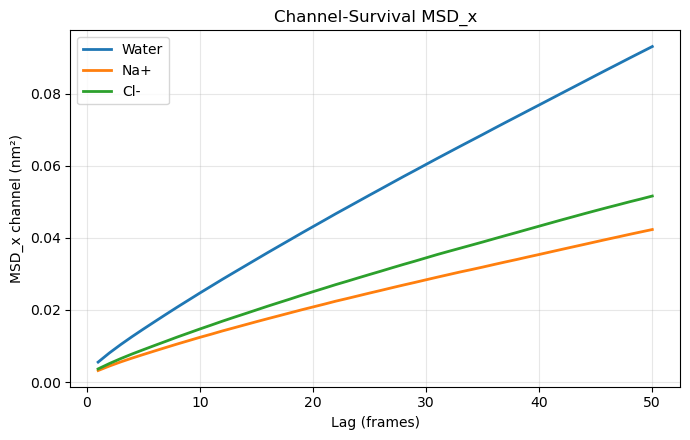

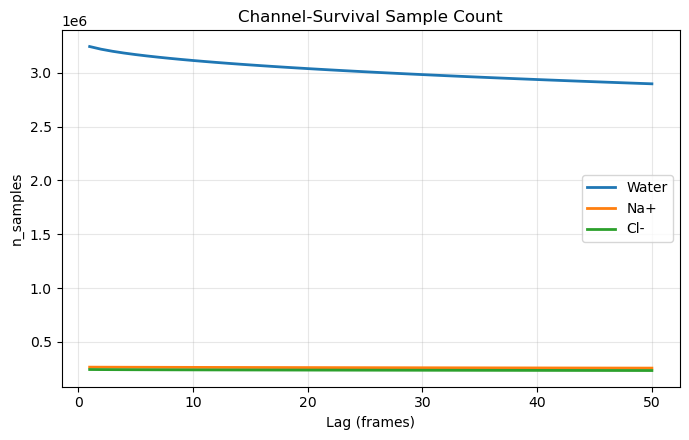

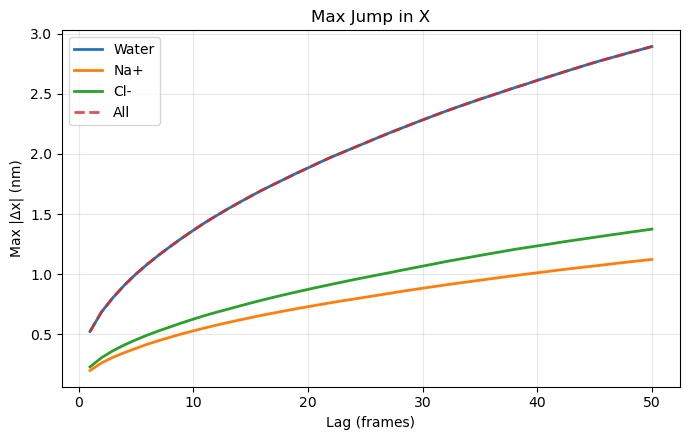

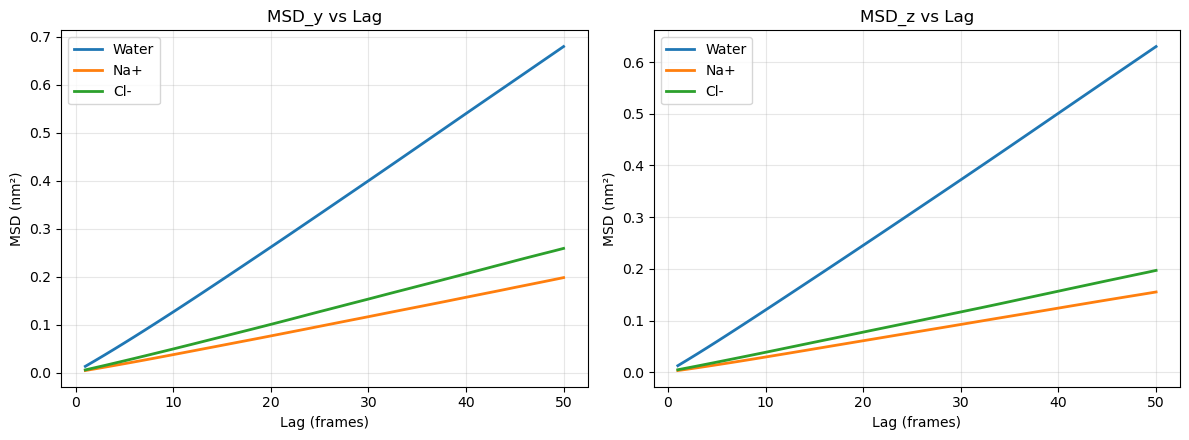

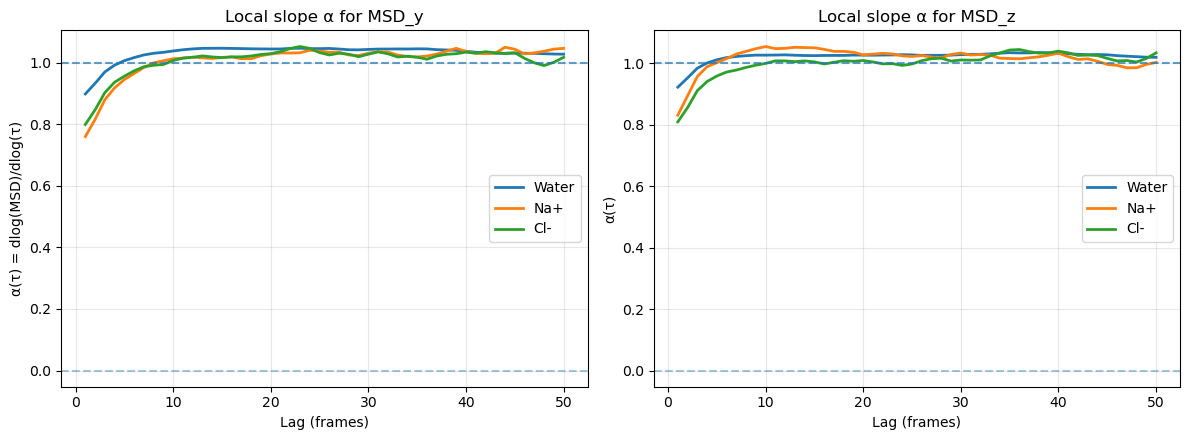

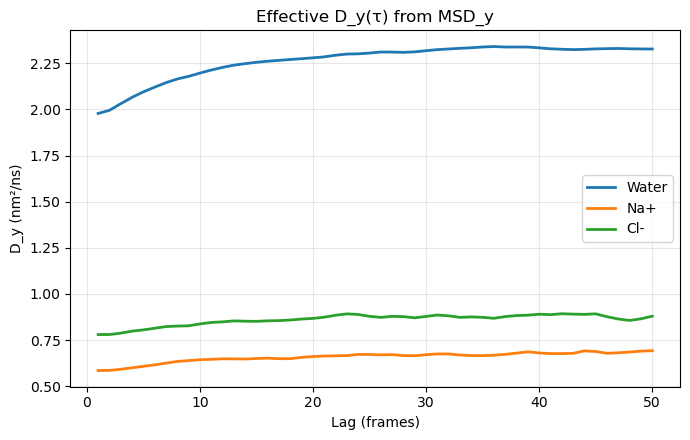

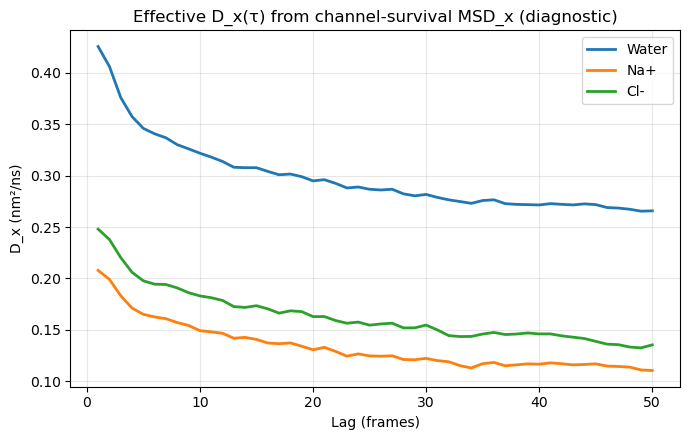

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# user settings
# -----------------------------
dt_ps = 3.0          # frame spacing in ps (CHANGE if needed)
ps_to_ns = 1e-3
eps = 1e-30          # avoid log(0)

# -----------------------------
# load data
# -----------------------------
df_ch = pd.read_csv("analysis_msd_x_channel.csv")
df_j  = pd.read_csv("analysis_jump_msd.csv")

# add lag time
df_ch["lag_ps"] = df_ch["lag_frames"] * dt_ps
df_ch["lag_ns"] = df_ch["lag_ps"] * ps_to_ns
df_j["lag_ps"]  = df_j["lag_frames"] * dt_ps
df_j["lag_ns"]  = df_j["lag_ps"] * ps_to_ns

# -----------------------------
# helpers
# -----------------------------
def local_loglog_slope(x, y):
    """alpha = d log(y) / d log(x) using numpy gradient. x,y must be >0."""
    x = np.asarray(x)
    y = np.asarray(y)
    m = (x > 0) & (y > 0) & np.isfinite(x) & np.isfinite(y)
    alpha = np.full_like(x, np.nan, dtype=float)
    if m.sum() >= 3:
        lx = np.log(x[m])
        ly = np.log(y[m])
        alpha_m = np.gradient(ly, lx)
        alpha[m] = alpha_m
    return alpha

def effective_D_1d(t, msd):
    """
    Effective diffusion coefficient from 1D MSD:
    D(t) ~ (1/2) d(MSD)/dt
    t in ns, msd in nm^2 -> D in nm^2/ns
    """
    t = np.asarray(t)
    msd = np.asarray(msd)
    m = np.isfinite(t) & np.isfinite(msd)
    D = np.full_like(t, np.nan, dtype=float)
    if m.sum() >= 3:
        dmsd_dt = np.gradient(msd[m], t[m])
        D[m] = 0.5 * dmsd_dt
    return D

# -----------------------------
# 1) Channel-survival MSD_x + sample counts
# -----------------------------
fig, ax = plt.subplots(figsize=(7,4.5))
ax.plot(df_ch["lag_frames"], df_ch["msd_x_channel_water_nm2_mean"], label="Water", lw=2)
ax.plot(df_ch["lag_frames"], df_ch["msd_x_channel_na_nm2_mean"], label="Na+", lw=2)
ax.plot(df_ch["lag_frames"], df_ch["msd_x_channel_cl_nm2_mean"], label="Cl-", lw=2)
ax.set_xlabel("Lag (frames)")
ax.set_ylabel("MSD_x channel (nm²)")
ax.set_title("Channel-Survival MSD_x")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7,4.5))
ax.plot(df_ch["lag_frames"], df_ch["n_samples_water"], label="Water", lw=2)
ax.plot(df_ch["lag_frames"], df_ch["n_samples_na"], label="Na+", lw=2)
ax.plot(df_ch["lag_frames"], df_ch["n_samples_cl"], label="Cl-", lw=2)
ax.set_xlabel("Lag (frames)")
ax.set_ylabel("n_samples")
ax.set_title("Channel-Survival Sample Count")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

# -----------------------------
# 2) Max jump in x
# -----------------------------
fig, ax = plt.subplots(figsize=(7,4.5))
ax.plot(df_j["lag_frames"], df_j["max_jump_x_water_nm_mean"], label="Water", lw=2)
ax.plot(df_j["lag_frames"], df_j["max_jump_x_na_nm_mean"], label="Na+", lw=2)
ax.plot(df_j["lag_frames"], df_j["max_jump_x_cl_nm_mean"], label="Cl-", lw=2)
if "max_jump_x_nm_mean" in df_j.columns:
    ax.plot(df_j["lag_frames"], df_j["max_jump_x_nm_mean"], label="All", lw=2, ls="--", alpha=0.8)
ax.set_xlabel("Lag (frames)")
ax.set_ylabel("Max |Δx| (nm)")
ax.set_title("Max Jump in X")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

# -----------------------------
# 3) MSD_y and MSD_z (z-slab restricted) + expected checks (alpha and D)
# -----------------------------
species = [("water", "Water"), ("na", "Na+"), ("cl", "Cl-")]

# --- MSD_y and MSD_z plots
fig, axs = plt.subplots(1, 2, figsize=(12,4.5), sharex=True)

for key, label in species:
    axs[0].plot(df_j["lag_frames"], df_j[f"msd_y_{key}_nm2_mean"], label=label, lw=2)
axs[0].set_title("MSD_y vs Lag")
axs[0].set_xlabel("Lag (frames)")
axs[0].set_ylabel("MSD (nm²)")
axs[0].grid(alpha=0.3)
axs[0].legend()

for key, label in species:
    axs[1].plot(df_j["lag_frames"], df_j[f"msd_z_{key}_nm2_mean"], label=label, lw=2)
axs[1].set_title("MSD_z vs Lag")
axs[1].set_xlabel("Lag (frames)")
axs[1].set_ylabel("MSD (nm²)")
axs[1].grid(alpha=0.3)
axs[1].legend()

plt.tight_layout()
plt.show()

# --- Local log-log slope alpha(tau) for MSD_y and MSD_z
fig, axs = plt.subplots(1, 2, figsize=(12,4.5), sharex=True)

tau = df_j["lag_ps"].values  # use ps for slope; any positive scale works
for key, label in species:
    msd_y = df_j[f"msd_y_{key}_nm2_mean"].values + eps
    alpha_y = local_loglog_slope(tau, msd_y)
    axs[0].plot(df_j["lag_frames"], alpha_y, label=label, lw=2)
axs[0].axhline(1.0, ls="--", alpha=0.7)
axs[0].axhline(0.0, ls="--", alpha=0.4)
axs[0].set_title("Local slope α for MSD_y")
axs[0].set_xlabel("Lag (frames)")
axs[0].set_ylabel("α(τ) = dlog(MSD)/dlog(τ)")
axs[0].grid(alpha=0.3)
axs[0].legend()

for key, label in species:
    msd_z = df_j[f"msd_z_{key}_nm2_mean"].values + eps
    alpha_z = local_loglog_slope(tau, msd_z)
    axs[1].plot(df_j["lag_frames"], alpha_z, label=label, lw=2)
axs[1].axhline(1.0, ls="--", alpha=0.7)
axs[1].axhline(0.0, ls="--", alpha=0.4)
axs[1].set_title("Local slope α for MSD_z")
axs[1].set_xlabel("Lag (frames)")
axs[1].set_ylabel("α(τ)")
axs[1].grid(alpha=0.3)
axs[1].legend()

plt.tight_layout()
plt.show()

# --- Effective diffusion coefficient from MSD_y (most meaningful in your setup)
# D in nm^2/ns; convert to m^2/s if you want: 1 nm^2/ns = 1e-9 m^2/s
fig, ax = plt.subplots(figsize=(7,4.5))
t_ns = df_j["lag_ns"].values

for key, label in species:
    msd_y = df_j[f"msd_y_{key}_nm2_mean"].values
    D_y = effective_D_1d(t_ns, msd_y)
    ax.plot(df_j["lag_frames"], D_y, label=label, lw=2)

ax.set_title("Effective D_y(τ) from MSD_y")
ax.set_xlabel("Lag (frames)")
ax.set_ylabel("D_y (nm²/ns)")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

# --- Optional: Effective D for channel-survival MSD_x (interpret carefully)
fig, ax = plt.subplots(figsize=(7,4.5))
t_ns_ch = df_ch["lag_ns"].values

for key, label in species:
    col = f"msd_x_channel_{key}_nm2_mean"
    if col in df_ch.columns:
        D_x_ch = effective_D_1d(t_ns_ch, df_ch[col].values)
        ax.plot(df_ch["lag_frames"], D_x_ch, label=label, lw=2)

ax.set_title("Effective D_x(τ) from channel-survival MSD_x (diagnostic)")
ax.set_xlabel("Lag (frames)")
ax.set_ylabel("D_x (nm²/ns)")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

In [11]:
import numpy as np

# ===============================
# USER SETTINGS
# ===============================
dt_ps = 3.0          # change if needed
ps_to_ns = 1e-3
fit_lag_min = 5      # frames (ignore very short ballistic regime)
fit_lag_max = 30     # frames (avoid survival collapse region)

# ===============================
# HELPER
# ===============================
def linear_fit_slope(x, y):
    m = np.isfinite(x) & np.isfinite(y)
    x = x[m]
    y = y[m]
    if len(x) < 3:
        return np.nan
    p = np.polyfit(x, y, 1)
    return p[0]

def loglog_alpha(x, y):
    m = (x > 0) & (y > 0) & np.isfinite(x) & np.isfinite(y)
    if m.sum() < 3:
        return np.nan
    lx = np.log(x[m])
    ly = np.log(y[m])
    alpha = np.gradient(ly, lx)
    return np.nanmean(alpha)

# ===============================
# PREPARE TIME AXIS
# ===============================
df_j["lag_ps"] = df_j["lag_frames"] * dt_ps
df_j["lag_ns"] = df_j["lag_ps"] * ps_to_ns
df_ch["lag_ps"] = df_ch["lag_frames"] * dt_ps
df_ch["lag_ns"] = df_ch["lag_ps"] * ps_to_ns

mask_fit_j = (df_j["lag_frames"] >= fit_lag_min) & (df_j["lag_frames"] <= fit_lag_max)
mask_fit_ch = (df_ch["lag_frames"] >= fit_lag_min) & (df_ch["lag_frames"] <= fit_lag_max)

# ===============================
# PRINT DIAGNOSTICS
# ===============================
print("\n==================== MSD DIAGNOSTICS ====================\n")

species = [("water", "Water"), ("na", "Na+"), ("cl", "Cl-")]

# ---- MSD_y diagnostics (should be diffusive)
print("---- MSD_y (expected diffusive regime) ----")
for key, label in species:
    msd = df_j[f"msd_y_{key}_nm2_mean"].values
    t_ns = df_j["lag_ns"].values
    
    slope = linear_fit_slope(t_ns[mask_fit_j], msd[mask_fit_j])
    D_est = 0.5 * slope  # 1D relation
    alpha_mean = loglog_alpha(df_j["lag_ps"].values, msd)
    
    print(f"{label}:")
    print(f"  Linear slope d(MSD)/dt (nm^2/ns): {slope:.4e}")
    print(f"  Estimated D_y (nm^2/ns):          {D_est:.4e}")
    print(f"  Mean log-log slope α:             {alpha_mean:.3f}")
    print()

# ---- MSD_z diagnostics (should saturate)
print("---- MSD_z (expected confinement) ----")
for key, label in species:
    msd = df_j[f"msd_z_{key}_nm2_mean"].values
    alpha_mean = loglog_alpha(df_j["lag_ps"].values, msd)
    print(f"{label}: Mean log-log slope α ≈ {alpha_mean:.3f}")
print()

# ---- Channel MSD_x diagnostics
print("---- Channel-survival MSD_x ----")
for key, label in species:
    col = f"msd_x_channel_{key}_nm2_mean"
    if col not in df_ch.columns:
        continue
    
    msd = df_ch[col].values
    t_ns = df_ch["lag_ns"].values
    
    slope = linear_fit_slope(t_ns[mask_fit_ch], msd[mask_fit_ch])
    D_est = 0.5 * slope
    alpha_mean = loglog_alpha(df_ch["lag_ps"].values, msd)
    
    n_samples_start = df_ch[f"n_samples_{key}"].iloc[0]
    n_samples_end   = df_ch[f"n_samples_{key}"].iloc[-1]
    
    print(f"{label}:")
    print(f"  Linear slope d(MSD)/dt (nm^2/ns): {slope:.4e}")
    print(f"  Estimated D_x_channel (nm^2/ns):  {D_est:.4e}")
    print(f"  Mean log-log slope α:             {alpha_mean:.3f}")
    print(f"  n_samples first lag:              {n_samples_start}")
    print(f"  n_samples last lag:               {n_samples_end}")
    print()

print("=========================================================\n")


==================== MSD DIAGNOSTICS ====================

---- MSD_y (expected diffusive regime) ----
Water:
  Linear slope d(MSD)/dt (nm^2/ns): 4.5180e+00
  Estimated D_y (nm^2/ns):          2.2590e+00
  Mean log-log slope α:             1.031

Na+:
  Linear slope d(MSD)/dt (nm^2/ns): 1.3086e+00
  Estimated D_y (nm^2/ns):          6.5430e-01
  Mean log-log slope α:             1.009

Cl-:
  Linear slope d(MSD)/dt (nm^2/ns): 1.7207e+00
  Estimated D_y (nm^2/ns):          8.6035e-01
  Mean log-log slope α:             1.007

---- MSD_z (expected confinement) ----
Water: Mean log-log slope α ≈ 1.022
Na+: Mean log-log slope α ≈ 1.016
Cl-: Mean log-log slope α ≈ 1.000

---- Channel-survival MSD_x ----
Water:
  Linear slope d(MSD)/dt (nm^2/ns): 6.0596e-01
  Estimated D_x_channel (nm^2/ns):  3.0298e-01
  Mean log-log slope α:             0.807
  n_samples first lag:              3244121
  n_samples last lag:               2897688

Na+:
  Linear slope d(MSD)/dt (nm^2/ns): 2.7448e-01
  Estim

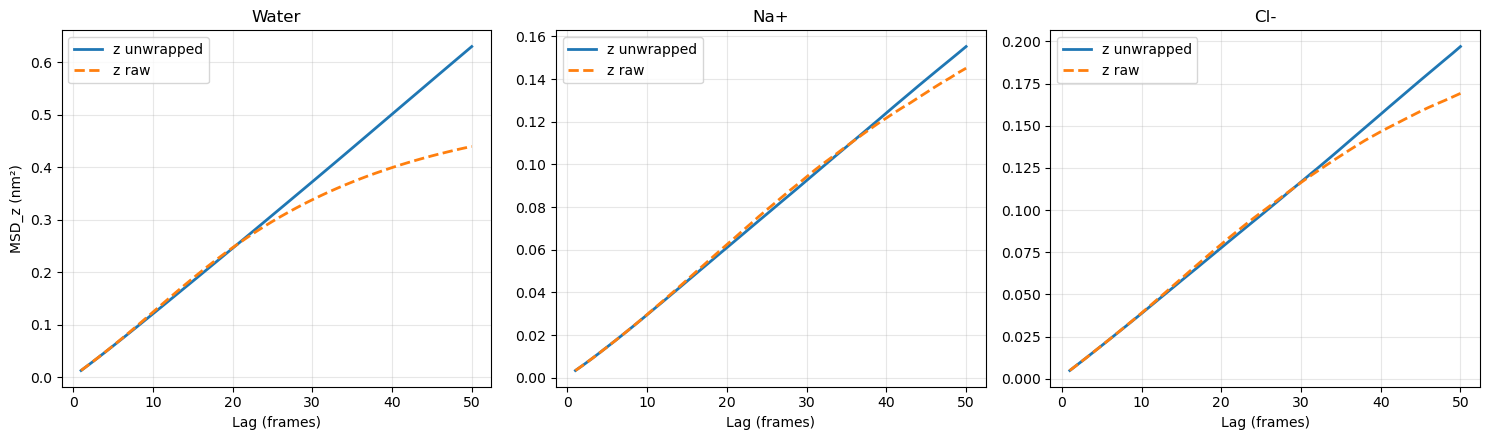


=========== MSD_z NUMERIC CHECK ===========

Water:
  Unwrapped: first=1.2693e-02, last=6.2996e-01, ratio(last/first)=49.63
  Raw      : first=1.2783e-02, last=4.3966e-01, ratio(last/first)=34.39

Na+:
  Unwrapped: first=3.3731e-03, last=1.5528e-01, ratio(last/first)=46.03
  Raw      : first=3.3731e-03, last=1.4513e-01, ratio(last/first)=43.03

Cl-:
  Unwrapped: first=4.8441e-03, last=1.9700e-01, ratio(last/first)=40.67
  Raw      : first=4.8441e-03, last=1.6921e-01, ratio(last/first)=34.93


=========== MSD_z SLOPE CHECK ===========

Water:
  alpha_unwrapped ≈ 1.022
  alpha_raw       ≈ 0.748

Na+:
  alpha_unwrapped ≈ 1.016
  alpha_raw       ≈ 0.946

Cl-:
  alpha_unwrapped ≈ 1.000
  alpha_raw       ≈ 0.866



In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Load
# -----------------------------
df = pd.read_csv("analysis_jump_msd.csv")

# -----------------------------
# Plot: MSD_z unwrapped vs raw
# -----------------------------
fig, axs = plt.subplots(1, 3, figsize=(15, 4.5), sharex=True)

# Water
axs[0].plot(df["lag_frames"], df["msd_z_water_nm2_mean"], label="z unwrapped", lw=2)
axs[0].plot(df["lag_frames"], df["msd_z_raw_water_nm2_mean"], label="z raw", lw=2, ls="--")
axs[0].set_title("Water")
axs[0].set_xlabel("Lag (frames)")
axs[0].set_ylabel("MSD_z (nm²)")
axs[0].grid(alpha=0.3)
axs[0].legend()

# Na
axs[1].plot(df["lag_frames"], df["msd_z_na_nm2_mean"], label="z unwrapped", lw=2)
axs[1].plot(df["lag_frames"], df["msd_z_raw_na_nm2_mean"], label="z raw", lw=2, ls="--")
axs[1].set_title("Na+")
axs[1].set_xlabel("Lag (frames)")
axs[1].grid(alpha=0.3)
axs[1].legend()

# Cl
axs[2].plot(df["lag_frames"], df["msd_z_cl_nm2_mean"], label="z unwrapped", lw=2)
axs[2].plot(df["lag_frames"], df["msd_z_raw_cl_nm2_mean"], label="z raw", lw=2, ls="--")
axs[2].set_title("Cl-")
axs[2].set_xlabel("Lag (frames)")
axs[2].grid(alpha=0.3)
axs[2].legend()

plt.tight_layout()
plt.show()

# -----------------------------
# Diagnostics printing helpers
# -----------------------------
def safe_ratio(a, b):
    if not np.isfinite(a) or not np.isfinite(b) or abs(b) < 1e-30:
        return np.nan
    return a / b

def loglog_alpha(x, y):
    """
    Mean local slope alpha = d log(y) / d log(x).
    Requires x>0 and y>0.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    m = (x > 0) & (y > 0) & np.isfinite(x) & np.isfinite(y)
    if m.sum() < 3:
        return np.nan
    lx = np.log(x[m])
    ly = np.log(y[m])
    alpha = np.gradient(ly, lx)
    return float(np.nanmean(alpha))

# -----------------------------
# Numeric check: first/last/ratio
# -----------------------------
print("\n=========== MSD_z NUMERIC CHECK ===========\n")

species = [("water", "Water"), ("na", "Na+"), ("cl", "Cl-")]

for key, label in species:
    col_un  = f"msd_z_{key}_nm2_mean"
    col_raw = f"msd_z_raw_{key}_nm2_mean"

    if col_un not in df.columns or col_raw not in df.columns:
        print(f"{label}: missing columns ({col_un} or {col_raw})")
        continue

    msd_un = df[col_un].to_numpy(dtype=float)
    msd_raw = df[col_raw].to_numpy(dtype=float)

    first_un, last_un = msd_un[0], msd_un[-1]
    first_raw, last_raw = msd_raw[0], msd_raw[-1]

    print(f"{label}:")
    print(f"  Unwrapped: first={first_un:.4e}, last={last_un:.4e}, ratio(last/first)={safe_ratio(last_un, first_un):.2f}")
    print(f"  Raw      : first={first_raw:.4e}, last={last_raw:.4e}, ratio(last/first)={safe_ratio(last_raw, first_raw):.2f}")
    print()

# -----------------------------
# Slope check: mean log-log alpha
# -----------------------------
print("\n=========== MSD_z SLOPE CHECK ===========\n")

lag = df["lag_frames"].to_numpy(dtype=float)  # any positive scale works

for key, label in species:
    col_un  = f"msd_z_{key}_nm2_mean"
    col_raw = f"msd_z_raw_{key}_nm2_mean"

    if col_un not in df.columns or col_raw not in df.columns:
        print(f"{label}: missing columns ({col_un} or {col_raw})")
        continue

    alpha_un  = loglog_alpha(lag, df[col_un].to_numpy(dtype=float))
    alpha_raw = loglog_alpha(lag, df[col_raw].to_numpy(dtype=float))

    print(f"{label}:")
    print(f"  alpha_unwrapped ≈ {alpha_un:.3f}")
    print(f"  alpha_raw       ≈ {alpha_raw:.3f}")
    print()

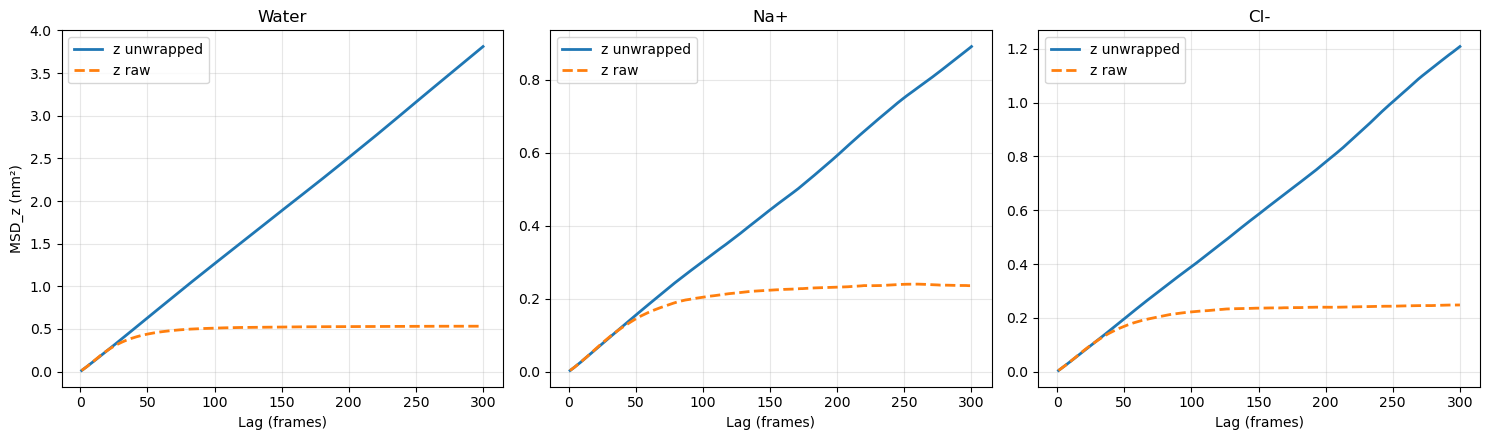


=========== MSD_z NUMERIC CHECK ===========

Water:
  Unwrapped: first=1.2693e-02, last=3.8116e+00, ratio(last/first)=300.29
  Raw      : first=1.2783e-02, last=5.3226e-01, ratio(last/first)=41.64

Na+:
  Unwrapped: first=3.3731e-03, last=8.9148e-01, ratio(last/first)=264.29
  Raw      : first=3.3731e-03, last=2.3607e-01, ratio(last/first)=69.99

Cl-:
  Unwrapped: first=4.8441e-03, last=1.2079e+00, ratio(last/first)=249.35
  Raw      : first=4.8441e-03, last=2.4826e-01, ratio(last/first)=51.25


=========== MSD_z SLOPE CHECK ===========

Water:
  alpha_unwrapped ≈ 1.011
  alpha_raw       ≈ 0.179

Na+:
  alpha_unwrapped ≈ 0.988
  alpha_raw       ≈ 0.302

Cl-:
  alpha_unwrapped ≈ 1.021
  alpha_raw       ≈ 0.267



In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Load
# -----------------------------
df = pd.read_csv("analysis_new_jump_msd.csv")

# -----------------------------
# Plot: MSD_z unwrapped vs raw
# -----------------------------
fig, axs = plt.subplots(1, 3, figsize=(15, 4.5), sharex=True)

# Water
axs[0].plot(df["lag_frames"], df["msd_z_water_nm2_mean"], label="z unwrapped", lw=2)
axs[0].plot(df["lag_frames"], df["msd_z_raw_water_nm2_mean"], label="z raw", lw=2, ls="--")
axs[0].set_title("Water")
axs[0].set_xlabel("Lag (frames)")
axs[0].set_ylabel("MSD_z (nm²)")
axs[0].grid(alpha=0.3)
axs[0].legend()

# Na
axs[1].plot(df["lag_frames"], df["msd_z_na_nm2_mean"], label="z unwrapped", lw=2)
axs[1].plot(df["lag_frames"], df["msd_z_raw_na_nm2_mean"], label="z raw", lw=2, ls="--")
axs[1].set_title("Na+")
axs[1].set_xlabel("Lag (frames)")
axs[1].grid(alpha=0.3)
axs[1].legend()

# Cl
axs[2].plot(df["lag_frames"], df["msd_z_cl_nm2_mean"], label="z unwrapped", lw=2)
axs[2].plot(df["lag_frames"], df["msd_z_raw_cl_nm2_mean"], label="z raw", lw=2, ls="--")
axs[2].set_title("Cl-")
axs[2].set_xlabel("Lag (frames)")
axs[2].grid(alpha=0.3)
axs[2].legend()

plt.tight_layout()
plt.show()

# -----------------------------
# Diagnostics printing helpers
# -----------------------------
def safe_ratio(a, b):
    if not np.isfinite(a) or not np.isfinite(b) or abs(b) < 1e-30:
        return np.nan
    return a / b

def loglog_alpha(x, y):
    """
    Mean local slope alpha = d log(y) / d log(x).
    Requires x>0 and y>0.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    m = (x > 0) & (y > 0) & np.isfinite(x) & np.isfinite(y)
    if m.sum() < 3:
        return np.nan
    lx = np.log(x[m])
    ly = np.log(y[m])
    alpha = np.gradient(ly, lx)
    return float(np.nanmean(alpha))

# -----------------------------
# Numeric check: first/last/ratio
# -----------------------------
print("\n=========== MSD_z NUMERIC CHECK ===========\n")

species = [("water", "Water"), ("na", "Na+"), ("cl", "Cl-")]

for key, label in species:
    col_un  = f"msd_z_{key}_nm2_mean"
    col_raw = f"msd_z_raw_{key}_nm2_mean"

    if col_un not in df.columns or col_raw not in df.columns:
        print(f"{label}: missing columns ({col_un} or {col_raw})")
        continue

    msd_un = df[col_un].to_numpy(dtype=float)
    msd_raw = df[col_raw].to_numpy(dtype=float)

    first_un, last_un = msd_un[0], msd_un[-1]
    first_raw, last_raw = msd_raw[0], msd_raw[-1]

    print(f"{label}:")
    print(f"  Unwrapped: first={first_un:.4e}, last={last_un:.4e}, ratio(last/first)={safe_ratio(last_un, first_un):.2f}")
    print(f"  Raw      : first={first_raw:.4e}, last={last_raw:.4e}, ratio(last/first)={safe_ratio(last_raw, first_raw):.2f}")
    print()

# -----------------------------
# Slope check: mean log-log alpha
# -----------------------------
print("\n=========== MSD_z SLOPE CHECK ===========\n")

lag = df["lag_frames"].to_numpy(dtype=float)  # any positive scale works

for key, label in species:
    col_un  = f"msd_z_{key}_nm2_mean"
    col_raw = f"msd_z_raw_{key}_nm2_mean"

    if col_un not in df.columns or col_raw not in df.columns:
        print(f"{label}: missing columns ({col_un} or {col_raw})")
        continue

    alpha_un  = loglog_alpha(lag, df[col_un].to_numpy(dtype=float))
    alpha_raw = loglog_alpha(lag, df[col_raw].to_numpy(dtype=float))

    print(f"{label}:")
    print(f"  alpha_unwrapped ≈ {alpha_un:.3f}")
    print(f"  alpha_raw       ≈ {alpha_raw:.3f}")
    print()

In [15]:
import pandas as pd
import numpy as np

df = pd.read_csv("analysis_msd_z_channel.csv")
last = df.iloc[-1]

def rel_diff(a,b):
    a=float(a); b=float(b)
    if a==0 and b==0: return 0.0
    return abs(a-b)/max(abs(a),abs(b),1e-30)

print("\n=== Channel MSD_z: raw vs unwrapped at LAST lag ===")
for sp in ["water","na","cl"]:
    u = last[f"msd_z_channel_unwrapped_{sp}_nm2_mean"]
    r = last[f"msd_z_channel_raw_{sp}_nm2_mean"]
    n = last[f"n_samples_{sp}"]
    m = last[f"max_abs_dz_lag1_{sp}_nm"]
    print(f"{sp:5s}: msd_unwrapped={u:.6g}  msd_raw={r:.6g}  rel_diff={rel_diff(u,r):.3e}  n={int(n)}  max|dz|@lag1={m:.6g} nm")

print("\n=== max_abs_dz_lag1 summary (min/median/max) ===")
for sp in ["water","na","cl"]:
    arr = df[f"max_abs_dz_lag1_{sp}_nm"].to_numpy()
    arr = arr[np.isfinite(arr)]
    if len(arr)==0: 
        print(sp, "no data"); continue
    print(f"{sp:5s}: min={np.min(arr):.6g}  median={np.median(arr):.6g}  max={np.max(arr):.6g} nm")


=== Channel MSD_z: raw vs unwrapped at LAST lag ===
water: msd_unwrapped=0.0111795  msd_raw=0.0113146  rel_diff=1.194e-02  n=24677  max|dz|@lag1=0.324 nm
na   : msd_unwrapped=0.00321414  msd_raw=0.00321414  rel_diff=0.000e+00  n=1850  max|dz|@lag1=0.227 nm
cl   : msd_unwrapped=0.003524  msd_raw=0.003524  rel_diff=0.000e+00  n=1680  max|dz|@lag1=0.152 nm

=== max_abs_dz_lag1 summary (min/median/max) ===
water: min=0.324  median=0.324  max=0.324 nm
na   : min=0.227  median=0.227  max=0.227 nm
cl   : min=0.152  median=0.152  max=0.152 nm


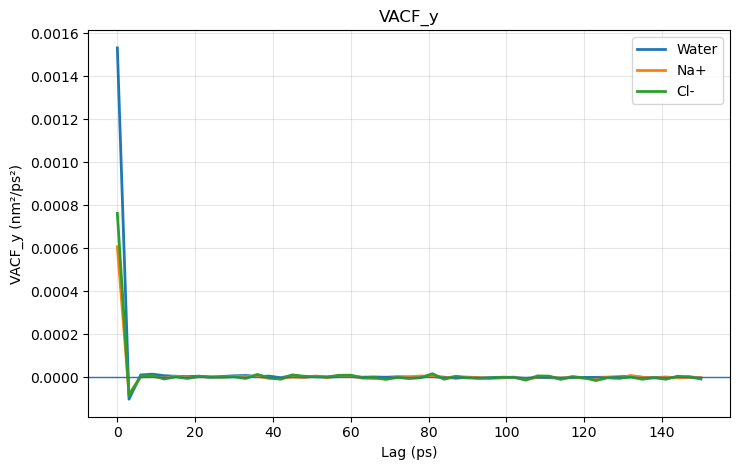

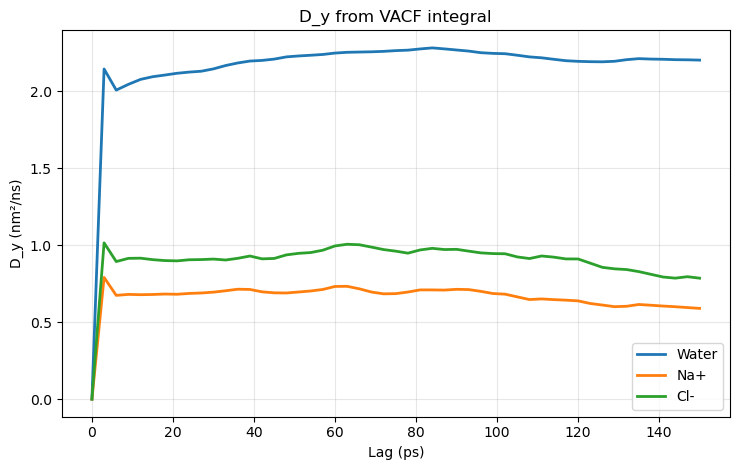

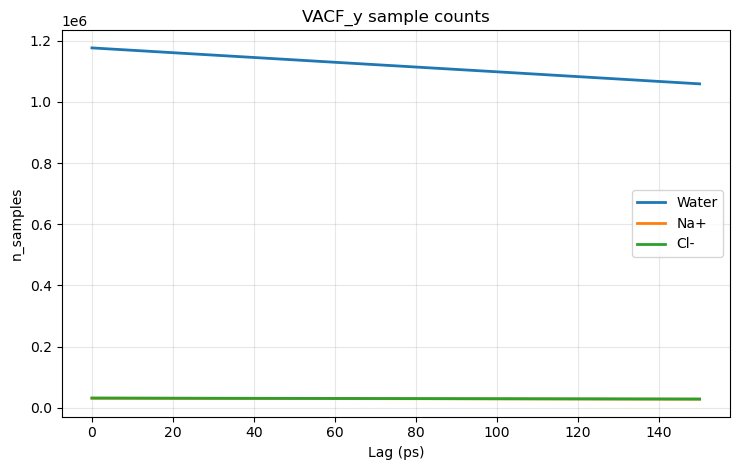

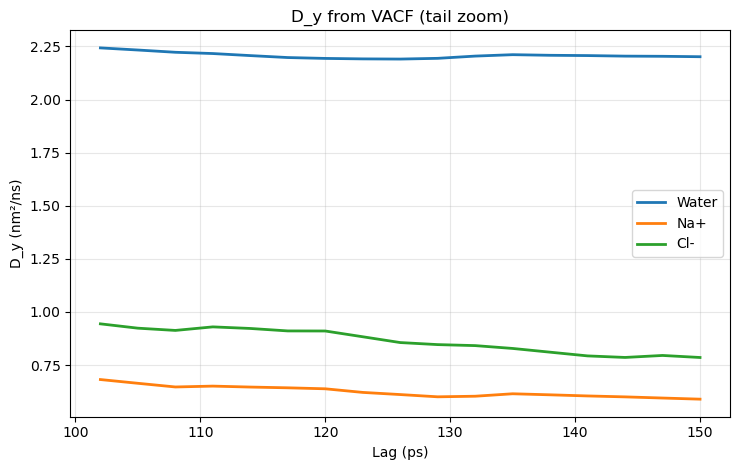

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Load
# -----------------------------
df = pd.read_csv("analysis_vacf_y.csv")

# Fix: your header has a stray leading ']' in the first column name.
# Rename it to 'lag_frames' if needed.
first_col = df.columns[0]
if first_col != "lag_frames":
    df = df.rename(columns={first_col: "lag_frames"})

# -----------------------------
# 1) VACF_y vs lag (ps)
# -----------------------------
fig, ax = plt.subplots(figsize=(7.5, 4.8))

ax.plot(df["lag_ps"], df["vacf_y_water_nm2_per_ps2"], label="Water", lw=2)
ax.plot(df["lag_ps"], df["vacf_y_na_nm2_per_ps2"], label="Na+", lw=2)
ax.plot(df["lag_ps"], df["vacf_y_cl_nm2_per_ps2"], label="Cl-", lw=2)

ax.axhline(0, lw=1)
ax.set_xlabel("Lag (ps)")
ax.set_ylabel("VACF_y (nm²/ps²)")
ax.set_title("VACF_y")
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

# -----------------------------
# 2) Integrated VACF -> D_y (nm^2/ns)
# -----------------------------
fig, ax = plt.subplots(figsize=(7.5, 4.8))

ax.plot(df["lag_ps"], df["D_y_from_vacf_water_nm2_per_ps"] * 1000, label="Water", lw=2)
ax.plot(df["lag_ps"], df["D_y_from_vacf_na_nm2_per_ps"] * 1000, label="Na+", lw=2)
ax.plot(df["lag_ps"], df["D_y_from_vacf_cl_nm2_per_ps"] * 1000, label="Cl-", lw=2)

ax.set_xlabel("Lag (ps)")
ax.set_ylabel("D_y (nm²/ns)")
ax.set_title("D_y from VACF integral")
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

# -----------------------------
# 3) Samples vs lag
# -----------------------------
fig, ax = plt.subplots(figsize=(7.5, 4.8))

ax.plot(df["lag_ps"], df["n_samples_water"], label="Water", lw=2)
ax.plot(df["lag_ps"], df["n_samples_na"], label="Na+", lw=2)
ax.plot(df["lag_ps"], df["n_samples_cl"], label="Cl-", lw=2)

ax.set_xlabel("Lag (ps)")
ax.set_ylabel("n_samples")
ax.set_title("VACF_y sample counts")
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

# -----------------------------
# 4) Zoomed D_y tail (last ~1/3) to see plateau drift
# -----------------------------
tail_start = int(len(df) * 2 / 3)

fig, ax = plt.subplots(figsize=(7.5, 4.8))

ax.plot(df["lag_ps"].iloc[tail_start:], df["D_y_from_vacf_water_nm2_per_ps"].iloc[tail_start:] * 1000, label="Water", lw=2)
ax.plot(df["lag_ps"].iloc[tail_start:], df["D_y_from_vacf_na_nm2_per_ps"].iloc[tail_start:] * 1000, label="Na+", lw=2)
ax.plot(df["lag_ps"].iloc[tail_start:], df["D_y_from_vacf_cl_nm2_per_ps"].iloc[tail_start:] * 1000, label="Cl-", lw=2)

ax.set_xlabel("Lag (ps)")
ax.set_ylabel("D_y (nm²/ns)")
ax.set_title("D_y from VACF (tail zoom)")
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

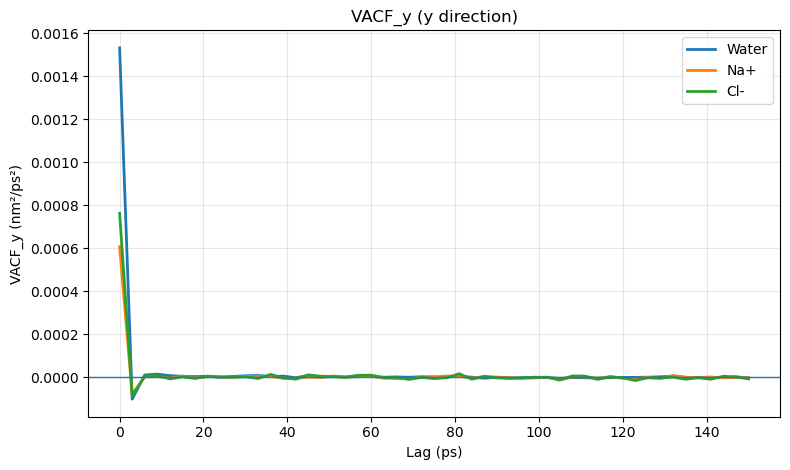

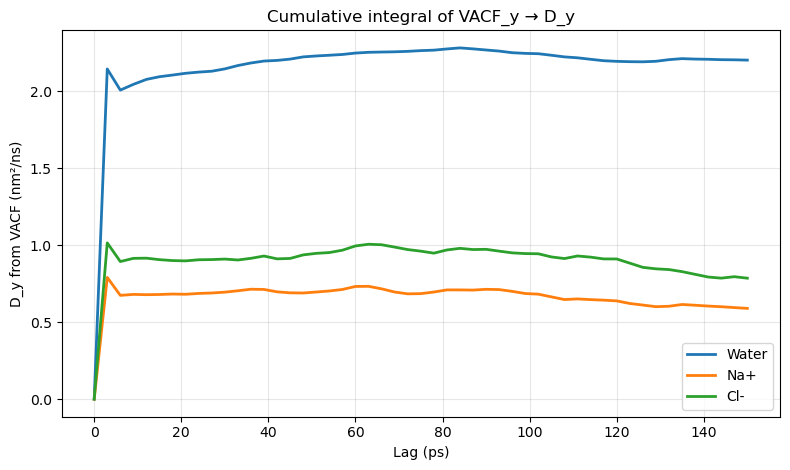

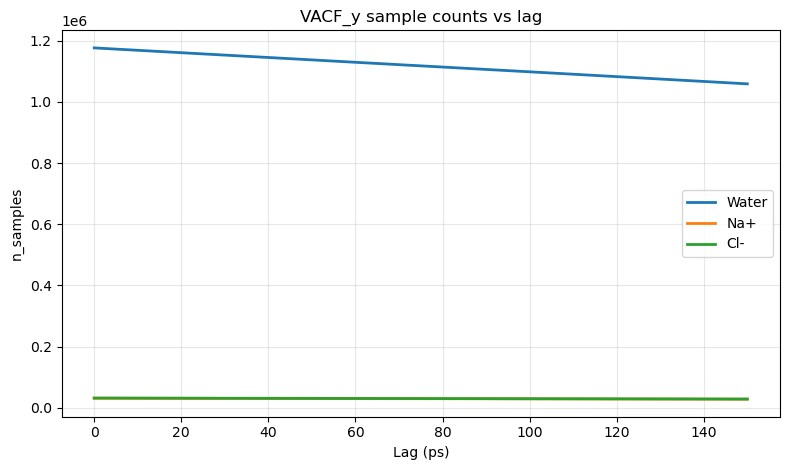

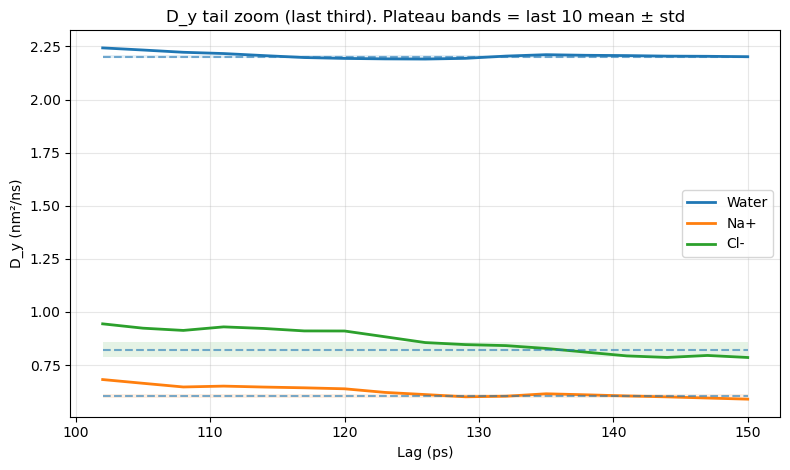

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("analysis_vacf_y.csv")

# Fix possible stray leading bracket in header (you had "]lag_frames")
if df.columns[0] != "lag_frames":
    df = df.rename(columns={df.columns[0]: "lag_frames"})

# Convenience: convert D from nm^2/ps -> nm^2/ns
def D_ns(col):
    return df[col] * 1000.0

# -------------- 1) VACF_y --------------
fig, ax = plt.subplots(figsize=(8, 4.8))
ax.plot(df["lag_ps"], df["vacf_y_water_nm2_per_ps2"], label="Water", lw=2)
ax.plot(df["lag_ps"], df["vacf_y_na_nm2_per_ps2"], label="Na+", lw=2)
ax.plot(df["lag_ps"], df["vacf_y_cl_nm2_per_ps2"], label="Cl-", lw=2)
ax.axhline(0, lw=1)
ax.set_xlabel("Lag (ps)")
ax.set_ylabel("VACF_y (nm²/ps²)")
ax.set_title("VACF_y (y direction)")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

# -------------- 2) Integrated VACF -> D_y (nm^2/ns) --------------
fig, ax = plt.subplots(figsize=(8, 4.8))
ax.plot(df["lag_ps"], D_ns("D_y_from_vacf_water_nm2_per_ps"), label="Water", lw=2)
ax.plot(df["lag_ps"], D_ns("D_y_from_vacf_na_nm2_per_ps"), label="Na+", lw=2)
ax.plot(df["lag_ps"], D_ns("D_y_from_vacf_cl_nm2_per_ps"), label="Cl-", lw=2)
ax.set_xlabel("Lag (ps)")
ax.set_ylabel("D_y from VACF (nm²/ns)")
ax.set_title("Cumulative integral of VACF_y → D_y")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

# -------------- 3) Sample counts --------------
fig, ax = plt.subplots(figsize=(8, 4.8))
ax.plot(df["lag_ps"], df["n_samples_water"], label="Water", lw=2)
ax.plot(df["lag_ps"], df["n_samples_na"], label="Na+", lw=2)
ax.plot(df["lag_ps"], df["n_samples_cl"], label="Cl-", lw=2)
ax.set_xlabel("Lag (ps)")
ax.set_ylabel("n_samples")
ax.set_title("VACF_y sample counts vs lag")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

# -------------- 4) Tail zoom of D_y + plateau band (last 10 mean ± std) --------------
tail_n = 10
tail = df.tail(tail_n)

plateau = {
    "Water": (tail["D_y_from_vacf_water_nm2_per_ps"].mean() * 1000.0, tail["D_y_from_vacf_water_nm2_per_ps"].std() * 1000.0),
    "Na+":   (tail["D_y_from_vacf_na_nm2_per_ps"].mean() * 1000.0,    tail["D_y_from_vacf_na_nm2_per_ps"].std() * 1000.0),
    "Cl-":   (tail["D_y_from_vacf_cl_nm2_per_ps"].mean() * 1000.0,    tail["D_y_from_vacf_cl_nm2_per_ps"].std() * 1000.0),
}

# Zoom region: last third of lags
tail_start = int(len(df) * 2 / 3)

fig, ax = plt.subplots(figsize=(8, 4.8))
ax.plot(df["lag_ps"].iloc[tail_start:], D_ns("D_y_from_vacf_water_nm2_per_ps").iloc[tail_start:], label="Water", lw=2)
ax.plot(df["lag_ps"].iloc[tail_start:], D_ns("D_y_from_vacf_na_nm2_per_ps").iloc[tail_start:], label="Na+", lw=2)
ax.plot(df["lag_ps"].iloc[tail_start:], D_ns("D_y_from_vacf_cl_nm2_per_ps").iloc[tail_start:], label="Cl-", lw=2)

# Plateau bands (mean ± 1 std) as horizontal spans
x0 = df["lag_ps"].iloc[tail_start]
x1 = df["lag_ps"].iloc[-1]
for lbl, (mu, sd) in plateau.items():
    ax.hlines(mu, x0, x1, linestyles="--", alpha=0.6)
    ax.fill_between([x0, x1], [mu - sd, mu - sd], [mu + sd, mu + sd], alpha=0.12)

ax.set_xlabel("Lag (ps)")
ax.set_ylabel("D_y (nm²/ns)")
ax.set_title(f"D_y tail zoom (last third). Plateau bands = last {tail_n} mean ± std")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

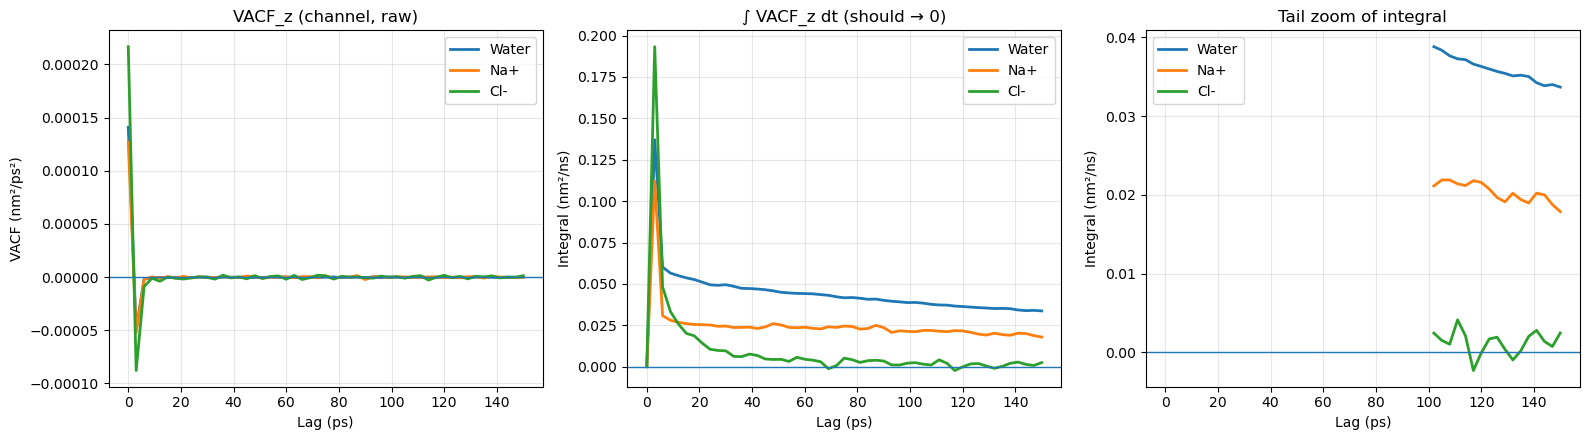

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("analysis_vacf_z_channel_raw.csv")

# Integral scale to nm^2/ns for easier comparison
Iz_w = df["I_z_from_vacf_channel_raw_water_nm2_per_ps"] * 1000.0
Iz_na = df["I_z_from_vacf_channel_raw_na_nm2_per_ps"] * 1000.0
Iz_cl = df["I_z_from_vacf_channel_raw_cl_nm2_per_ps"] * 1000.0

fig, axs = plt.subplots(1, 3, figsize=(16, 4.5), sharex=True)

# (1) VACF_z
axs[0].plot(df["lag_ps"], df["vacf_z_channel_raw_water_nm2_per_ps2"], label="Water", lw=2)
axs[0].plot(df["lag_ps"], df["vacf_z_channel_raw_na_nm2_per_ps2"], label="Na+", lw=2)
axs[0].plot(df["lag_ps"], df["vacf_z_channel_raw_cl_nm2_per_ps2"], label="Cl-", lw=2)
axs[0].axhline(0.0, lw=1)
axs[0].set_title("VACF_z (channel, raw)")
axs[0].set_xlabel("Lag (ps)")
axs[0].set_ylabel("VACF (nm²/ps²)")
axs[0].grid(alpha=0.3)
axs[0].legend()

# (2) Integral (full)
axs[1].plot(df["lag_ps"], Iz_w, label="Water", lw=2)
axs[1].plot(df["lag_ps"], Iz_na, label="Na+", lw=2)
axs[1].plot(df["lag_ps"], Iz_cl, label="Cl-", lw=2)
axs[1].axhline(0.0, lw=1)
axs[1].set_title("∫ VACF_z dt (should → 0)")
axs[1].set_xlabel("Lag (ps)")
axs[1].set_ylabel("Integral (nm²/ns)")
axs[1].grid(alpha=0.3)
axs[1].legend()

# (3) Integral tail zoom
tail_start = int(len(df) * 2 / 3)
axs[2].plot(df["lag_ps"].iloc[tail_start:], Iz_w.iloc[tail_start:], label="Water", lw=2)
axs[2].plot(df["lag_ps"].iloc[tail_start:], Iz_na.iloc[tail_start:], label="Na+", lw=2)
axs[2].plot(df["lag_ps"].iloc[tail_start:], Iz_cl.iloc[tail_start:], label="Cl-", lw=2)
axs[2].axhline(0.0, lw=1)
axs[2].set_title("Tail zoom of integral")
axs[2].set_xlabel("Lag (ps)")
axs[2].set_ylabel("Integral (nm²/ns)")
axs[2].grid(alpha=0.3)
axs[2].legend()

plt.tight_layout()
plt.show()

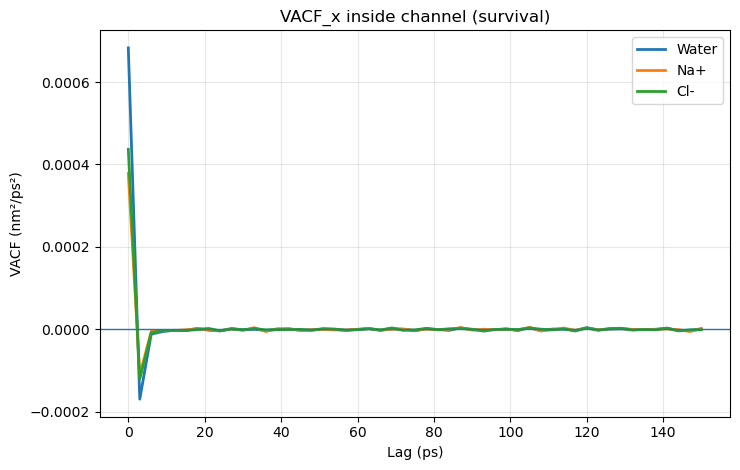

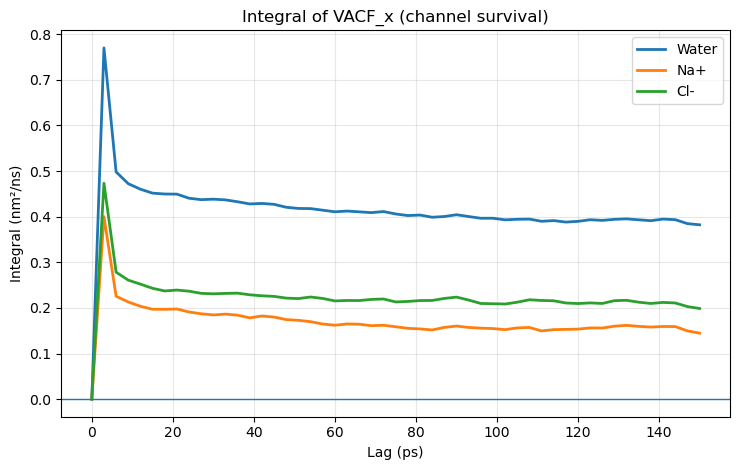

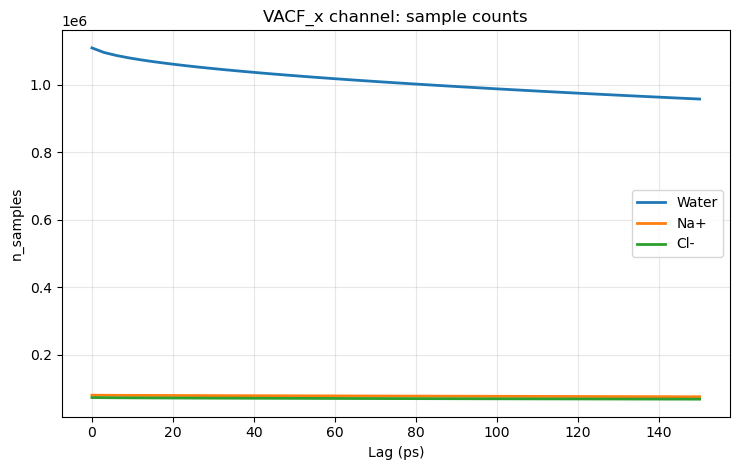

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("analysis_vacf_x_channel.csv")

# VACF_x
fig, ax = plt.subplots(figsize=(7.5, 4.8))
ax.plot(df["lag_ps"], df["vacf_x_channel_water_nm2_per_ps2"], label="Water", lw=2)
ax.plot(df["lag_ps"], df["vacf_x_channel_na_nm2_per_ps2"], label="Na+", lw=2)
ax.plot(df["lag_ps"], df["vacf_x_channel_cl_nm2_per_ps2"], label="Cl-", lw=2)
ax.axhline(0.0, lw=1)
ax.set_title("VACF_x inside channel (survival)")
ax.set_xlabel("Lag (ps)")
ax.set_ylabel("VACF (nm²/ps²)")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

# Integral (convert to nm^2/ns for readability: nm^2/ps * 1000)
fig, ax = plt.subplots(figsize=(7.5, 4.8))
ax.plot(df["lag_ps"], df["I_x_from_vacf_channel_water_nm2_per_ps"] * 1000, label="Water", lw=2)
ax.plot(df["lag_ps"], df["I_x_from_vacf_channel_na_nm2_per_ps"] * 1000, label="Na+", lw=2)
ax.plot(df["lag_ps"], df["I_x_from_vacf_channel_cl_nm2_per_ps"] * 1000, label="Cl-", lw=2)
ax.axhline(0.0, lw=1)
ax.set_title("Integral of VACF_x (channel survival)")
ax.set_xlabel("Lag (ps)")
ax.set_ylabel("Integral (nm²/ns)")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

# Sample counts
fig, ax = plt.subplots(figsize=(7.5, 4.8))
ax.plot(df["lag_ps"], df["n_samples_water"], label="Water", lw=2)
ax.plot(df["lag_ps"], df["n_samples_na"], label="Na+", lw=2)
ax.plot(df["lag_ps"], df["n_samples_cl"], label="Cl-", lw=2)
ax.set_title("VACF_x channel: sample counts")
ax.set_xlabel("Lag (ps)")
ax.set_ylabel("n_samples")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

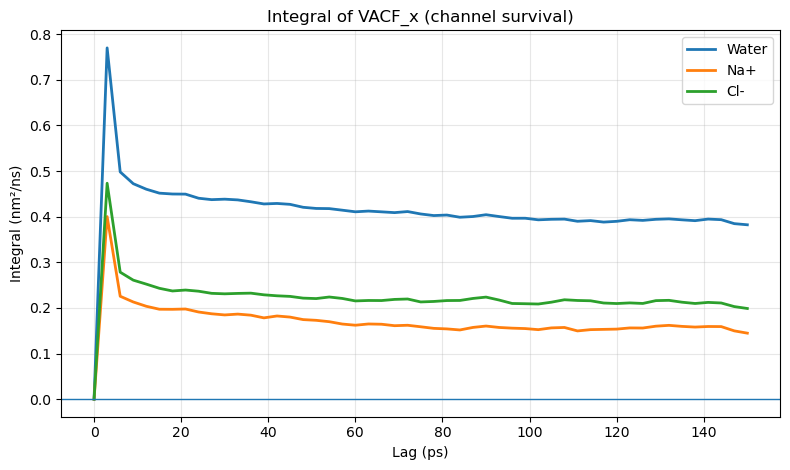

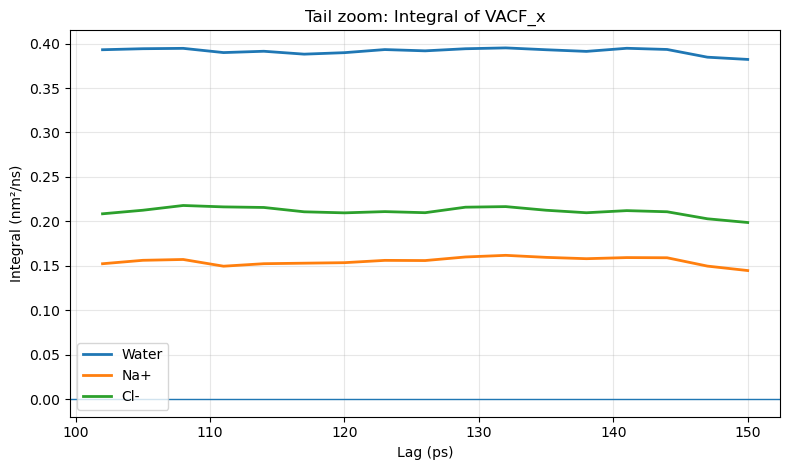

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("analysis_vacf_x_channel.csv")

Ix_w  = df["I_x_from_vacf_channel_water_nm2_per_ps"] * 1000
Ix_na = df["I_x_from_vacf_channel_na_nm2_per_ps"] * 1000
Ix_cl = df["I_x_from_vacf_channel_cl_nm2_per_ps"] * 1000

# Full integral
fig, ax = plt.subplots(figsize=(8,4.8))
ax.plot(df["lag_ps"], Ix_w,  label="Water", lw=2)
ax.plot(df["lag_ps"], Ix_na, label="Na+", lw=2)
ax.plot(df["lag_ps"], Ix_cl, label="Cl-", lw=2)
ax.axhline(0, lw=1)
ax.set_title("Integral of VACF_x (channel survival)")
ax.set_xlabel("Lag (ps)")
ax.set_ylabel("Integral (nm²/ns)")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

# Tail zoom
tail_start = int(len(df)*2/3)
fig, ax = plt.subplots(figsize=(8,4.8))
ax.plot(df["lag_ps"].iloc[tail_start:], Ix_w.iloc[tail_start:],  label="Water", lw=2)
ax.plot(df["lag_ps"].iloc[tail_start:], Ix_na.iloc[tail_start:], label="Na+", lw=2)
ax.plot(df["lag_ps"].iloc[tail_start:], Ix_cl.iloc[tail_start:], label="Cl-", lw=2)
ax.axhline(0, lw=1)
ax.set_title("Tail zoom: Integral of VACF_x")
ax.set_xlabel("Lag (ps)")
ax.set_ylabel("Integral (nm²/ns)")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


In [24]:
import numpy as np
import pandas as pd

df = pd.read_csv("analysis_vacf_x_channel.csv")

def summarize(col, name, n=10):
    tail = df[col].tail(n) * 1000  # nm^2/ns
    print(f"{name}: mean(last{n})={tail.mean():.6f} nm^2/ns   std={tail.std():.6f}")

summarize("I_x_from_vacf_channel_water_nm2_per_ps", "Water")
summarize("I_x_from_vacf_channel_na_nm2_per_ps", "Na+")
summarize("I_x_from_vacf_channel_cl_nm2_per_ps", "Cl-")

Water: mean(last10)=0.391377 nm^2/ns   std=0.004387
Na+: mean(last10)=0.156403 nm^2/ns   std=0.005294
Cl-: mean(last10)=0.210009 nm^2/ns   std=0.005467


In [25]:
import numpy as np
import pandas as pd

msd = pd.read_csv("analysis_msd_x_channel.csv")
vacf = pd.read_csv("analysis_vacf_x_channel.csv")

species = [
    ("water", "msd_x_channel_water_nm2_mean", "I_x_from_vacf_channel_water_nm2_per_ps", "n_samples_water"),
    ("na",    "msd_x_channel_na_nm2_mean",    "I_x_from_vacf_channel_na_nm2_per_ps",    "n_samples_na"),
    ("cl",    "msd_x_channel_cl_nm2_mean",    "I_x_from_vacf_channel_cl_nm2_per_ps",    "n_samples_cl"),
]

rows = []
for sp, msd_col, ix_col, n_col in species:
    m = msd[(msd["lag_frames"].between(30, 50)) & (msd[n_col] > 0) & (msd["lag_ps"] > 0)][
        ["lag_frames", "lag_ps", msd_col, n_col]
    ].copy()

    v = vacf[(vacf["lag_frames"].between(30, 50)) & (vacf[n_col] > 0) & (vacf["lag_ps"] > 0)][
        ["lag_frames", ix_col, n_col]
    ].copy()

    g = m.merge(v, on="lag_frames", suffixes=("_msd", "_vacf"))
    if len(g) < 2:
        rows.append([sp, np.nan, np.nan, np.nan, np.nan, len(g)])
        continue

    t = g["lag_ps"].to_numpy()
    y = g[msd_col].to_numpy()
    w = np.sqrt(g[f"{n_col}_msd"].to_numpy())

    slope = np.polyfit(t, y, 1, w=w)[0]          # d(MSD)/dt, nm^2/ps
    deff_msd = 0.5 * slope                        # 1D: D_eff = 0.5 dMSD/dt, nm^2/ps
    ix_mean = g[ix_col].mean()                    # mean I_x over lag window
    ix_last = g[ix_col].iloc[-1]                  # end-of-window I_x
    ratio = deff_msd / ix_mean if ix_mean != 0 else np.nan

    rows.append([sp, deff_msd, ix_mean, ix_last, ratio, len(g)])

out = pd.DataFrame(rows, columns=[
    "species",
    "D_eff_from_MSD_nm2_per_ps",
    "I_x_mean_30_50_nm2_per_ps",
    "I_x_last_50_nm2_per_ps",
    "D_eff_over_Ix_mean",
    "n_lags_used",
])

out


,species,D_eff_from_MSD_nm2_per_ps,I_x_mean_30_50_nm2_per_ps,I_x_last_50_nm2_per_ps,D_eff_over_Ix_mean,n_lags_used
0,water,0.000324,0.000393,0.000382,0.825131,21
1,na,0.000143,0.000156,0.000145,0.920303,21
2,cl,0.000190,0.000212,0.000199,0.896522,21
